# Trabajo Práctico 1 - Grupo 02

### Ejercicio 1

Integrantes:

*   Bermudez, Agustin
*   Calderón, Tiago
*   Gonzalez Pautaso, Mateo
*   Moreyra, Santiago
*   Nieves, Maylen

## Carga de datos

Para el desarrollo de este ejercicio se van a usar los datos correspondientes a viajes realizados en taxis **Yellow Cab** de la ciudad de Nueva York durante el período **enero–marzo de 2025**, obtenidos desde [NYC Taxi & Limousine Commission (TLC)](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page).

### Sobre el dataset
Los datos estan en formato `.parquet`. Se cargan directamente usando el método especifico para ello de `pandas`

Los tres archivos mensuales se concatenan en un único DataFrame para el análisis y se usa ignore_index en `true` para que el nuevo dataset cree un id nuevo.

Cada fila representa un viaje individual e incluye información relevante sobre el mismo. El significado de cada una de las columnas se puede interpretar a partir del [diccionario provisto por la TLC](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf):

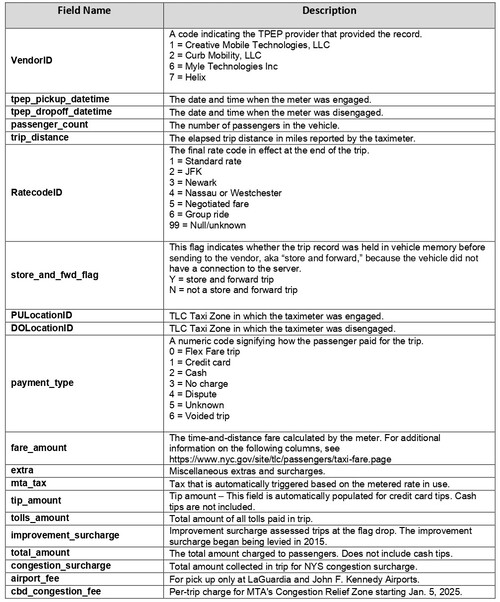

In [1]:
import pandas as pd
import numpy as np
import gc

#Visualizaciones
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
url_base = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{año}-{mes:02d}.parquet"

# Siempre muestra los números decimales con exactamente 2 decimales al imprimir, solo cosmético sin modificar datos
pd.set_option('display.float_format', '{:.2f}'.format)

df_enero = pd.read_parquet(url_base.format(año=2025, mes=1))
df_febrero = pd.read_parquet(url_base.format(año=2025, mes=2))
df_marzo = pd.read_parquet(url_base.format(año=2025, mes=3))

df = pd.concat([df_enero, df_febrero, df_marzo], ignore_index=True)

# Liberar los DataFrames mensuales inmediatamente
del df_enero, df_febrero, df_marzo
gc.collect()

0

In [3]:
# Ver las primeras filas
df.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.00,1.60,1.00,N,229,237,1,10.00,3.50,0.50,3.00,0.00,1.00,18.00,2.50,0.00,0.00
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.00,0.50,1.00,N,236,237,1,5.10,3.50,0.50,2.02,0.00,1.00,12.12,2.50,0.00,0.00
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.00,0.60,1.00,N,141,141,1,5.10,3.50,0.50,2.00,0.00,1.00,12.10,2.50,0.00,0.00
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.00,0.52,1.00,N,244,244,2,7.20,1.00,0.50,0.00,0.00,1.00,9.70,0.00,0.00,0.00
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.00,0.66,1.00,N,244,116,2,5.80,1.00,0.50,0.00,0.00,1.00,8.30,0.00,0.00,0.00
5,2,2025-01-01 00:48:24,2025-01-01 01:08:26,2.00,2.63,1.00,N,239,68,2,19.10,1.00,0.50,0.00,0.00,1.00,24.10,2.50,0.00,0.00
6,1,2025-01-01 00:14:47,2025-01-01 00:16:15,0.00,0.40,1.00,N,170,170,1,4.40,3.50,0.50,2.35,0.00,1.00,11.75,2.50,0.00,0.00
7,1,2025-01-01 00:39:27,2025-01-01 00:51:51,0.00,1.60,1.00,N,234,148,1,12.10,3.50,0.50,2.00,0.00,1.00,19.10,2.50,0.00,0.00
8,1,2025-01-01 00:53:43,2025-01-01 01:13:23,0.00,2.80,1.00,N,148,170,1,19.10,3.50,0.50,3.00,0.00,1.00,27.10,2.50,0.00,0.00
9,2,2025-01-01 00:00:02,2025-01-01 00:09:36,1.00,1.71,1.00,N,237,262,2,11.40,1.00,0.50,0.00,0.00,1.00,16.40,2.50,0.00,0.00


## Preguntas de investigación

A partir del dataset de viajes en Yellow Cab de Nueva York (enero–marzo 2025),
planteamos las siguientes preguntas de investigación que guiarán el análisis exploratorio.
Las respuestas se desarrollan al final del notebook, luego del preprocesamiento.

### 1) ¿Cómo varía la demanda de taxis a lo largo del día y la semana?
Hipótesis: esperamos encontrar picos de demanda durante la hora pico (mañana y tarde)
en días hábiles, y un patrón distinto los fines de semana con mayor actividad nocturna.


### 2) ¿Los viajes en hora pico son más lentos aunque recorran distancias similares?
Hipótesis: esperamos que en hora pico la duración sea mayor y la velocidad promedio menor,
aun cuando la distancia recorrida sea comparable a la de otros horarios, debido a la
congestión característica de Manhattan.

### 3) ¿Qué zonas y boroughs generan los viajes más rentables?
Hipótesis: esperamos que las zonas céntricas de Manhattan y las zonas aeroportuarias
de Queens concentren los viajes con mayor tarifa y propina combinadas.


### 4) ¿Cómo difiere el perfil económico de los viajes al aeropuerto vs. el resto?
Hipótesis: esperamos que los viajes al aeropuerto presenten tarifas y propinas
significativamente más altas, así como mayor distancia y duración, respecto al
viaje urbano típico.

### 5) ¿El comportamiento de la propina depende de la distancia del viaje y la cantidad de pasajeros?
Hipótesis: esperamos que a mayor distancia la tasa de propina sea más alta, dado que
el pasajero percibe un mayor servicio. Respecto a los pasajeros, no tenemos una hipótesis
clara: podría aumentar por el servicio compartido o mantenerse constante al ser
un porcentaje habitual de la tarifa.

## Estudio inicial del dataframe

El primer paso para saber el estado del dataframe sobre el que se desarrolla el ejercicio. Para esto primero analizamos el tamaño del mismo y el tipo de cada una de las variables.

In [4]:
# Analisis del tamaño del dataframe
f, c = df.shape
print(f'Cantidad de filas: {f}')
print(f'Cantidad de columnas: {c}')

Cantidad de filas: 11198026
Cantidad de columnas: 20


In [5]:
# Tipos de cada variable
df.dtypes

,0
VendorID,int32
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float64
trip_distance,float64
RatecodeID,float64
store_and_fwd_flag,object
PULocationID,int32
DOLocationID,int32
payment_type,int64


In [6]:
# Estadísticas descriptivas
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,11198026.00,11198026,11198026,8934277.00,11198026.00,8934277.00,11198026.00,11198026.00,11198026.00,11198026.00,11198026.00,11198026.00,11198026.00,11198026.00,11198026.00,11198026.00,8934277.00,8934277.00,11198026.00
mean,1.80,2025-02-17 03:02:19.286457,2025-02-17 03:17:49.412615,1.29,6.18,2.45,163.31,162.53,0.98,17.24,1.26,0.48,2.85,0.44,0.96,25.67,2.23,0.13,0.52
min,1.00,2007-12-05 18:45:00,2007-12-05 19:02:00,0.00,0.00,1.00,1.00,1.00,0.00,-1807.60,-9.25,-0.50,-220.00,-142.17,-1.00,-1832.85,-2.50,-1.75,-0.75
25%,2.00,2025-01-26 03:19:31,2025-01-26 03:31:36.250000,1.00,1.00,1.00,125.00,113.00,1.00,8.60,0.00,0.50,0.00,0.00,1.00,15.45,2.50,0.00,0.00
50%,2.00,2025-02-17 14:56:00,2025-02-17 15:11:05,1.00,1.72,1.00,161.00,162.00,1.00,12.80,0.00,0.50,2.25,0.00,1.00,20.25,2.50,0.00,0.75
75%,2.00,2025-03-11 08:14:55,2025-03-11 08:32:06.750000,1.00,3.24,1.00,233.00,234.00,1.00,20.50,2.50,0.50,3.90,0.00,1.00,28.42,2.50,0.00,0.75
max,7.00,2025-04-01 00:00:17,2025-04-03 14:07:50,9.00,320136.29,99.00,265.00,265.00,5.00,863372.12,22.55,10.50,440.00,916.87,1.00,863380.37,2.50,6.75,1.50
std,0.48,NaN,NaN,0.74,581.82,11.51,65.41,69.83,0.72,261.99,1.85,0.13,3.77,2.01,0.27,262.31,0.91,0.48,0.36


In [7]:
# Cantidad de valores unicos que toma cada variable
df.nunique()

,0
VendorID,4
tpep_pickup_datetime,5107022
tpep_dropoff_datetime,5103505
passenger_count,10
trip_distance,5927
RatecodeID,7
store_and_fwd_flag,2
PULocationID,261
DOLocationID,260
payment_type,6


In [8]:
# Cantidad de nulos que hay en cada variable
df.isna().sum()

,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,2263749
trip_distance,0
RatecodeID,2263749
store_and_fwd_flag,2263749
PULocationID,0
DOLocationID,0
payment_type,0


In [9]:
# Porcentaje de nulos por variable
(df.isna().sum() / len(df) * 100).round(2)

,0
VendorID,0.00
tpep_pickup_datetime,0.00
tpep_dropoff_datetime,0.00
passenger_count,20.22
trip_distance,0.00
RatecodeID,20.22
store_and_fwd_flag,20.22
PULocationID,0.00
DOLocationID,0.00
payment_type,0.00


### Clasificacion de las variables

Ya conociendo los significados de cada una de las variables presentes en el dataframe, se van a clasificar en sus distintos tipos (cualitativas o cuantitativas) y corregir dentro del dataframe en caso de que los tipos presentes sean inconsistentes con la realidad.

| Variable | Tipo estadístico | Tipo en pandas | Observaciones |
|---|---|---|---|
| `VendorID` | Cualitativa nominal | `int64` → `category` | Solo toma valores 1, 2, 6, 7 |
| `tpep_pickup_datetime` | Temporal | `datetime64` ||
| `tpep_dropoff_datetime` | Temporal | `datetime64` ||
| `passenger_count` | Cuantitativa discreta | `float64` → `Int64` | Tiene nulos |
| `trip_distance` | Cuantitativa continua | `float64` ||
| `RatecodeID` | Cualitativa nominal | `float64` → `category` | Tiene nulos / 99 significa nulo tambien|
| `store_and_fwd_flag` | Cualitativa nominal | `object` → `category` | Tiene nulos |
| `PULocationID` | Cualitativa nominal | `int64` → `category` | Código de zona TLC / 264 es nulo / 265 es cuasi nulo por ser fuera de NYC|
| `DOLocationID` | Cualitativa nominal | `int64` → `category` | Código de zona TLC / 264 es nulo / 265 es cuasi nulo por ser fuera de NYC|
| `payment_type` | Cualitativa nominal | `int64` → `category` |5 es desconocido|
| `fare_amount` | Cuantitativa continua | `float64` ||
| `extra` | Cuantitativa continua | `float64` ||
| `mta_tax` | Cuantitativa continua | `float64` ||
| `tip_amount` | Cuantitativa continua | `float64` |No mide propinas en efectivo|
| `tolls_amount` | Cuantitativa continua | `float64` ||
| `improvement_surcharge` | Cuantitativa continua | `float64` ||
| `total_amount` | Cuantitativa continua | `float64` ||
| `congestion_surcharge` | Cuantitativa continua | `float64` | Tiene nulos |
| `Airport_fee` | Cuantitativa continua | `float64` | Tiene nulos |
| `cbd_congestion_fee` | Cuantitativa continua | `float64` ||

### Corrección de los tipos de datos

In [10]:
df['VendorID'] = df['VendorID'].astype('category')
df['RatecodeID'] = df['RatecodeID'].astype('category')
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].astype('category')
df['PULocationID'] = df['PULocationID'].astype('category')
df['DOLocationID'] = df['DOLocationID'].astype('category')
df['payment_type'] = df['payment_type'].astype('category')

df.dtypes

,0
VendorID,category
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float64
trip_distance,float64
RatecodeID,category
store_and_fwd_flag,category
PULocationID,category
DOLocationID,category
payment_type,category


## Merge con zonas TLC

Consideramos que agregar los nombres de los Borough y otros datos, enriquecería la información de las zonas. Esto proporcionaría no solo un ID, sino que estaría junto a un nombre.

Estos datos fueron extraídos desde `taxi_zone_lookup.csv`, provisto por la TLC.

In [11]:
zonas = pd.read_csv('https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv')

zonas['LocationID'] = zonas['LocationID'].astype(df['PULocationID'].dtype)

df = df.merge(
    zonas.rename(columns={
        'LocationID': 'PULocationID',
        'Borough': 'pickup_borough',
        'Zone': 'pickup_zone',
        'service_zone': 'pickup_service_zone'
    }),
    on='PULocationID', how='left'
)

df = df.merge(
    zonas.rename(columns={
        'LocationID': 'DOLocationID',
        'Borough': 'dropoff_borough',
        'Zone': 'dropoff_zone',
        'service_zone': 'dropoff_service_zone'
    }),
    on='DOLocationID', how='left'
)

for col in ['pickup_borough', 'pickup_zone', 'dropoff_borough', 'dropoff_zone',
            'pickup_service_zone', 'dropoff_service_zone']:
    df[col] = df[col].astype('category')

df.dtypes

,0
VendorID,category
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float64
trip_distance,float64
RatecodeID,category
store_and_fwd_flag,category
PULocationID,category
DOLocationID,int32
payment_type,category


## Correlación entre variables cuantitativas

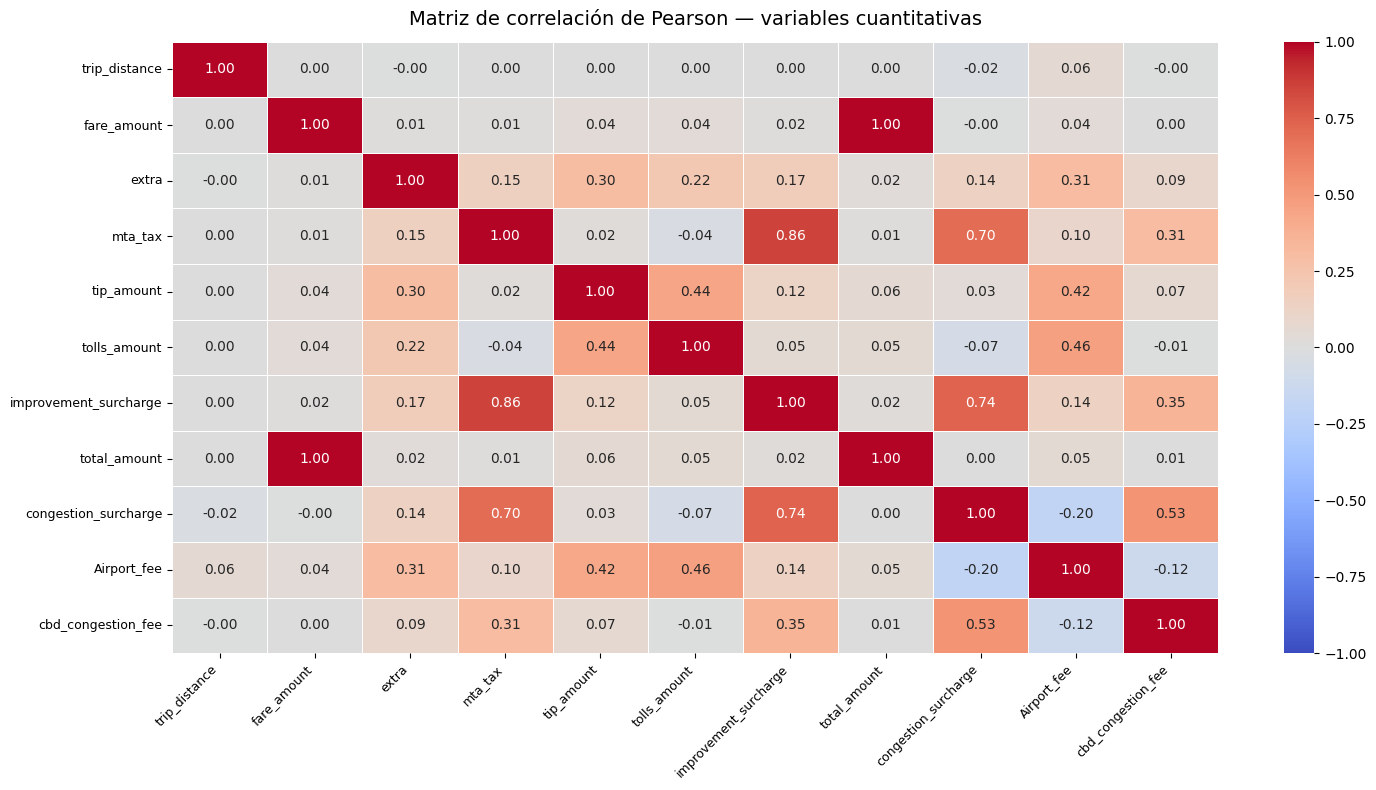

In [12]:
# Variables cuantitativas continuas según diccionario TLC
num_cols = [
    'trip_distance',
    'fare_amount',
    'extra',
    'mta_tax',
    'tip_amount',
    'tolls_amount',
    'improvement_surcharge',
    'total_amount',
    'congestion_surcharge',
    'Airport_fee',
    'cbd_congestion_fee'
]

# Correlación de Pearson
matriz_corr = df[num_cols].corr()

# Grafico la matriz de correlación en un Heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(
    matriz_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title('Matriz de correlación de Pearson — variables cuantitativas', fontsize=14, pad=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

### Correlaciones altas

- `fare_amount` y `total_amount`: tiene correlación 1, tiene sentido ya que `total_amount` es `fare_amount` más algunos cargos pequeños.
- `mta_tax` y `improvement_surcharge`: tiene correlación 0.86, tiene sentido ya que ambos son costos fijos que se aplican en los mismos viajes.
- `improvement_surcharge` y `congestion_surcharge`: tiene correlación 0.74, tiene sentido ya que se aplican en las mismas zonas.
- `mta_tax` y `congestion_surcharge`: tiene correlación 0.7, tiene sentido ya que se aplica en las mismas condiciones.

### Correlaciones medias

- `cbd_congestion_fee` y `congestion_surcharge`: 0.53, ambos se aplican en zonas congestionadas de Manhattan.
- `airport_fee` y `tolls_amount`: 0.46, tiene sentido que los viajes al aeropuerto pasen por peajes.
- `toll_amount` y `tip_amount`: 0.44, tiene sentido que los que hayan pasado por un peaje dejen una propina más alta porque puede ser un viaje más largo.
- `airport_fee` y `tip_amount`: 0.42, tiene sentido que los que vayan al aeropuerto dejen una propina más alta.

### Correlaciones bajas

- `trip_distance` y `fare_amount` tienen correlación 0.00038 lo cual es extraño ya que a mayor distancia debería ser un precio más elevado por lo que deberían tener una correlación alta. Puede ser que hayan valores atípicos.

## Exploración de variables cualitativas

A continuación se analizan las variables cualitativas del dataset mediante gráficos de distribución.

Dado que esta sección se realiza antes del preprocesamiento, todos los valores estan contenidos en los gráficos, incluyendo nulos o valores imposibles. Todo esto señalado en los gráficos

In [13]:
vendor_map = {1: 'VeriFone Inc.', 2: 'Creative Mobile Tech.', 6: 'Myle Technologies', 7: 'Helix'}
payment_map = {1: 'Credit card', 2: 'Cash', 3: 'No charge', 4: 'Dispute', 5: 'Unknown'}
ratecode_map = {1: 'Standard', 2: 'JFK', 3: 'Newark', 4: 'Nassau/Westchester', 5: 'Negotiated', 6: 'Group ride', 99: 'Inválido'}

### Distribución por proveedor (VendorID)

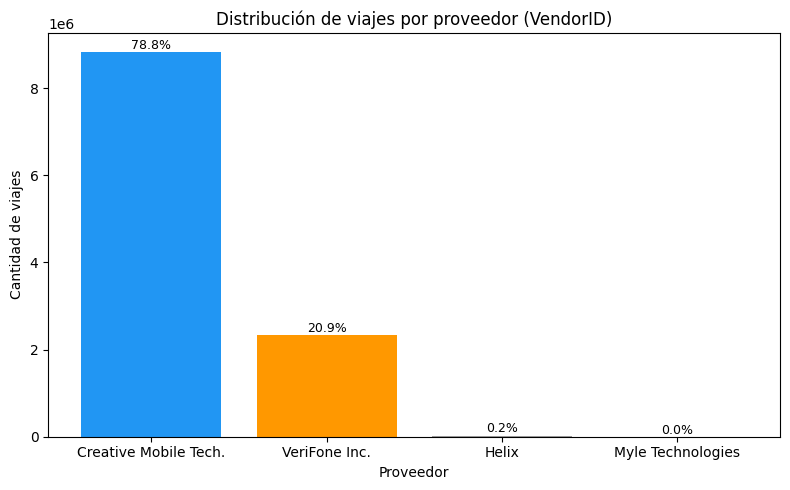

In [14]:
vendor_counts = df['VendorID'].value_counts(dropna=False).reset_index()
vendor_counts.columns = ['VendorID', 'count']
vendor_counts['label'] = vendor_counts['VendorID'].astype(str).map(
    {str(k): v for k, v in vendor_map.items()})
vendor_counts['pct'] = vendor_counts['count'] / vendor_counts['count'].sum() * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(vendor_counts['label'], vendor_counts['count'], color=['#2196F3', '#FF9800', '#9E9E9E', '#9E9E9E'])
ax.set_title('Distribución de viajes por proveedor (VendorID)')
ax.set_xlabel('Proveedor')
ax.set_ylabel('Cantidad de viajes')
for bar, pct in zip(bars, vendor_counts['pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1000,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()
plt.close('all')

Los proveedores mayoritarios son Creative Mobile Technologies (VendorID 2) y VeriFone Inc. (VendorID 1).

### Métodos de pago (payment_type)

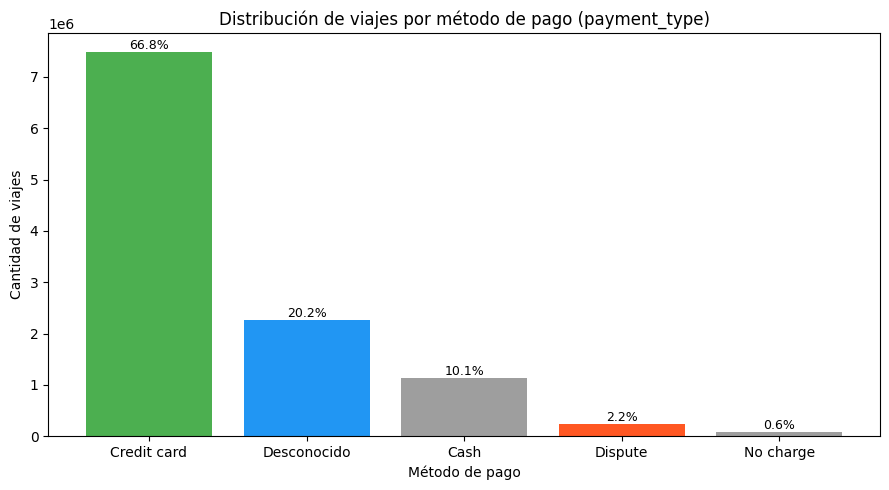

In [15]:
payment_counts = df['payment_type'].value_counts(dropna=False).reset_index()
payment_counts.columns = ['payment_type', 'count']
payment_counts['label'] = payment_counts['payment_type'].astype(str).map(
    {str(k): v for k, v in payment_map.items()}
).fillna('Desconocido')

# Colapsar 'Unknown' y 'Desconocido' en una sola categoría
payment_counts['label'] = payment_counts['label'].replace('Unknown', 'Desconocido')
payment_counts = payment_counts.groupby('label', as_index=False)['count'].sum()

payment_counts['pct'] = payment_counts['count'] / payment_counts['count'].sum() * 100
payment_counts = payment_counts.sort_values('count', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#4CAF50', '#2196F3', '#9E9E9E', '#FF5722', '#9E9E9E']
bars = ax.bar(payment_counts['label'], payment_counts['count'], color=colors[:len(payment_counts)])
ax.set_title('Distribución de viajes por método de pago (payment_type)')
ax.set_xlabel('Método de pago')
ax.set_ylabel('Cantidad de viajes')
for bar, pct in zip(bars, payment_counts['pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1000,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()
plt.close('all')

La tarjeta de crédito es el método de pago predominante, seguido por efectivo.
Cabe destacar que `tip_amount` no registra propinas abonadas en efectivo, lo que implica que el análisis de propinas en secciones posteriores estará sesgado hacia los pagos con tarjeta.



In [16]:
# Comparar distribución de tip_amount por método de pago
payment_label = df['payment_type'].astype(str)\
    .map({str(k): v for k, v in payment_map.items()})\
    .fillna('Desconocido')\
    .replace('Unknown', 'Desconocido')

tip_comparison = df.groupby(payment_label)['tip_amount'].agg(
    pct_sin_propina=lambda x: (x == 0).mean() * 100,
    propina_media=lambda x: x[x > 0].mean()
).round(2)

print(tip_comparison)

              pct_sin_propina  propina_media
payment_type                                
Cash                    99.95           6.13
Credit card              6.10           4.42
Desconocido             91.57           4.40
Dispute                 99.20           6.64
No charge               99.23           5.70


Analizando el gráfico de método de pago en relación a cantidad de viajes, llama la atención el 20,2% de viajes con método de pago "Desconocido". Esto podría llegar a interpretarse como posibles pagos en efectivo, pero registrados de la forma incorrecta, ya que si hubiesen sido con tarjeta de crédito estarían bancarizados automáticamente.

Para investigar esto, revisamos los porcentajes de viajes sin propina en relación al total de viajes. Se observa que el método de pago `Credit card` tiene solo 6,1% de viajes sin propina, mientras que `Cash` tiene casi la totalidad de sus viajes (99,95%) sin propina.

El grupo de viajes que tiene un método de pago `Desconocido` posee un 91,57% de viajes sin propina, lo que lo acerca a un comportamiento mas esperable del método `Cash` que `Credit Card`.

No consideramos que esta es información suficiente para catalogar a todos los pagos `Desconocido` como `Cash`, pero lo sugiere fuertemente.

### Tipo de tarifa (RatecodeID)

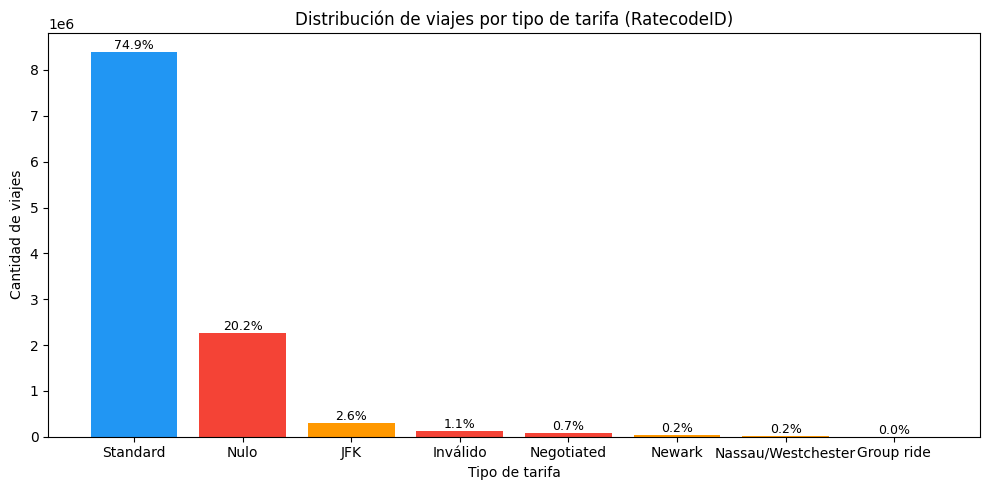

In [17]:
ratecode_counts = df['RatecodeID'].value_counts(dropna=False).reset_index()
ratecode_counts.columns = ['RatecodeID', 'count']

ratecode_counts['label'] = ratecode_counts['RatecodeID'].astype(str).map(
    {str(float(k)): v for k, v in ratecode_map.items()}
).fillna('Nulo')

ratecode_counts['pct'] = ratecode_counts['count'] / ratecode_counts['count'].sum() * 100
ratecode_counts = ratecode_counts.sort_values('count', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(ratecode_counts['label'], ratecode_counts['count'],
              color=['#2196F3' if l == 'Standard' else '#FF9800' if l in ['JFK', 'Newark', 'Nassau/Westchester']
                     else '#F44336' for l in ratecode_counts['label']])
ax.set_title('Distribución de viajes por tipo de tarifa (RatecodeID)')
ax.set_xlabel('Tipo de tarifa')
ax.set_ylabel('Cantidad de viajes')
for bar, pct in zip(bars, ratecode_counts['pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()
plt.close('all')

La tarifa estándar (RatecodeID 1) domina ampliamente. Los valores 99 y NaN son inválidos  según el diccionario TLC y serán tratados en la sección de valores faltantes.

### Zonas y boroughs más frecuentes

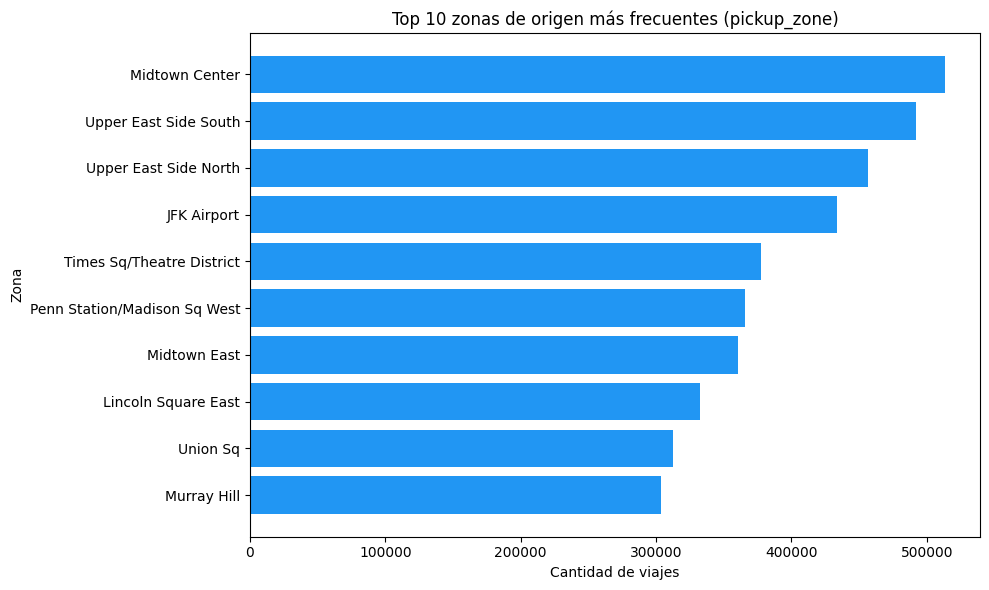

In [18]:
top_pu_zonas = (df['pickup_zone'].value_counts(dropna=True).head(10).reset_index())
top_pu_zonas.columns = ['zona', 'count']

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_pu_zonas['zona'][::-1], top_pu_zonas['count'][::-1], color='#2196F3')
ax.set_title('Top 10 zonas de origen más frecuentes (pickup_zone)')
ax.set_xlabel('Cantidad de viajes')
ax.set_ylabel('Zona')
plt.tight_layout()
plt.show()
plt.close('all')

A continuación analizamos las zonas que pueden resultar mas rentables para los conductores de los Yellow Cab.

La ganancia del trabajador esta compuesta por la tarifa base del viaje y el adicional de la propina. Para esto creamos una nueva variable `revenue` que simboliza este valor mencionado anteriormente.

Para este análisis solo se van a tener en cuenta los viajes cuyo método de pago fue `Credit Card`, ya que las propinas en efectivo no estan contempladas y los viajes con método `Cash` tienen este valor faltante.

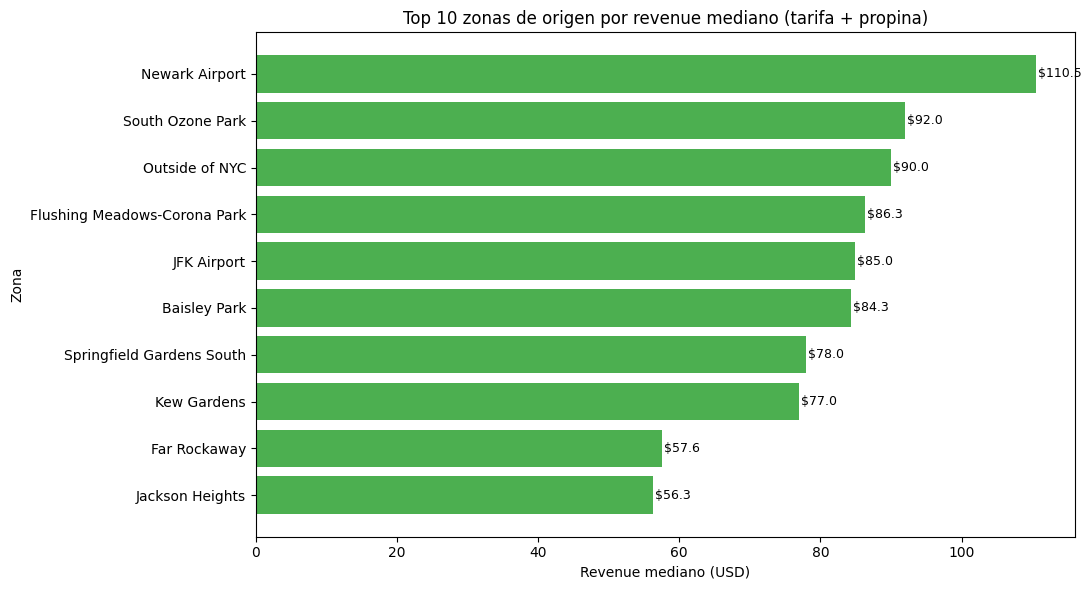

In [19]:
df['revenue'] = np.where(
    df['payment_type'] == 1,
    df['fare_amount'] + df['tip_amount'],
    np.nan)

# Top 10 zonas por revenue mediano (mínimo 500 viajes)
top_zones = (df.groupby('pickup_zone', observed=True)['revenue']
               .agg(['median','count'])
               .query('count >= 500')
               .sort_values('median', ascending=False)
               .head(10)
               .reset_index())

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top_zones['pickup_zone'][::-1], top_zones['median'][::-1], color='#4CAF50')
ax.set_title('Top 10 zonas de origen por revenue mediano (tarifa + propina)')
ax.set_xlabel('Revenue mediano (USD)')
ax.set_ylabel('Zona')
for i, (val, cnt) in enumerate(zip(top_zones['median'][::-1],
                                    top_zones['count'][::-1])):
    ax.text(val + 0.3, i, f'${val:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()
plt.close('all')


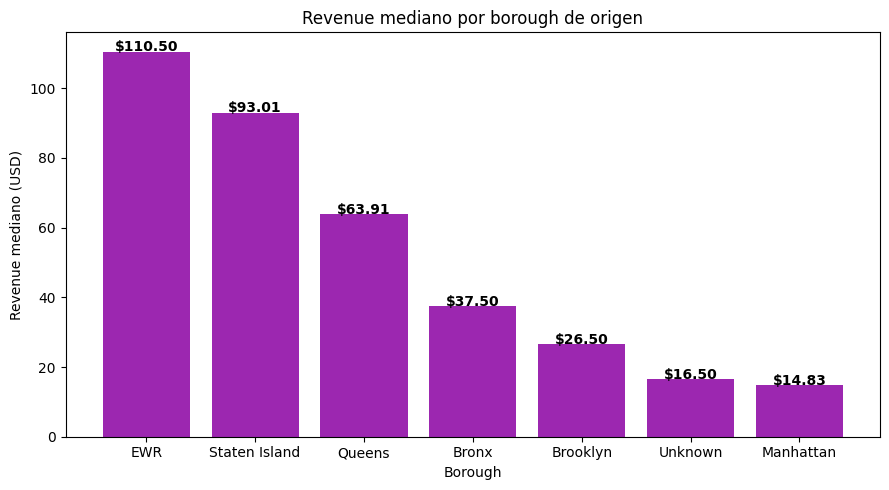

In [20]:
# Revenue mediano por borough
borough_rev = (df.groupby('pickup_borough', observed=True)['revenue']
                 .median()
                 .sort_values(ascending=False)
                 .reset_index())

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(borough_rev['pickup_borough'], borough_rev['revenue'], color='#9C27B0')
ax.set_title('Revenue mediano por borough de origen')
ax.set_xlabel('Borough')
ax.set_ylabel('Revenue mediano (USD)')
for bar, val in zip(bars, borough_rev['revenue']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'${val:.2f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close('all')

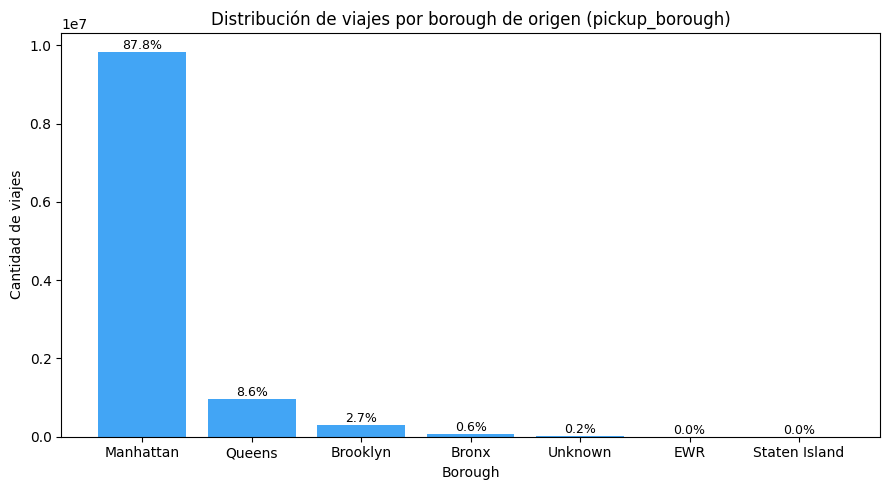

In [21]:
borough_counts = df['pickup_borough'].value_counts(dropna=True).reset_index()
borough_counts.columns = ['borough', 'count']
borough_counts['pct'] = borough_counts['count'] / borough_counts['count'].sum() * 100

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(borough_counts['borough'], borough_counts['count'], color='#42A5F5')
ax.set_title('Distribución de viajes por borough de origen (pickup_borough)')
ax.set_xlabel('Borough')
ax.set_ylabel('Cantidad de viajes')
for bar, pct in zip(bars, borough_counts['pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()
plt.close('all')

Manhattan concentra la gran mayoría de los viajes originados, lo cual es consistente  con ser el centro comercial y turístico de NYC. Queens ocupa el segundo lugar, impulsado principalmente por los viajes al aeropuerto JFK y LaGuardia.

### Análisis de consumo por hora y día

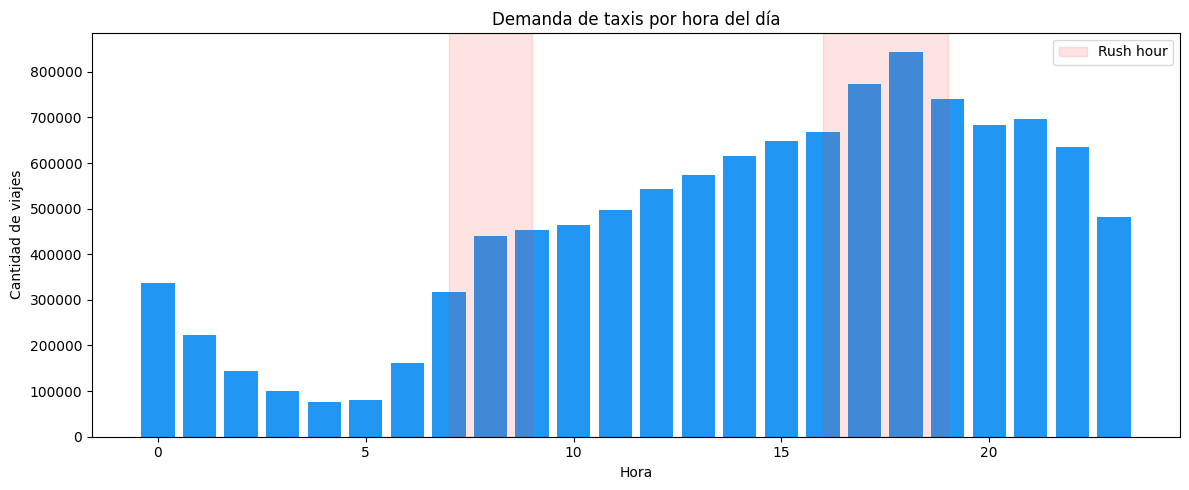

In [22]:
order_days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['hour']        = df['tpep_pickup_datetime'].dt.hour
df['day_of_week'] = df['tpep_pickup_datetime'].dt.day_name()

# Demanda por hora
demand_hour = df.groupby('hour').size().reset_index(name='viajes')

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(demand_hour['hour'], demand_hour['viajes'], color='#2196F3')
for start, end in [(7, 9), (16, 19)]:
    ax.axvspan(start, end, alpha=0.15, color='#F44336',
               label='Rush hour' if start == 7 else '')
ax.set_title('Demanda de taxis por hora del día')
ax.set_xlabel('Hora')
ax.set_ylabel('Cantidad de viajes')
ax.legend()
plt.tight_layout()
plt.show()
plt.close('all')

La demanda tiene una caída entre las 3-5 AM y dos subidas diferenciadas. El pico matutino (7-9 AM) es moderado (\~450k viajes), mientras que a la tarde (16-19 hs) es notoriamente más pronunciado, alcanzando el máximo absoluto a las 18 hs (\~840k viajes).

Esto sugiere que la demanda de regreso a casa supera ampliamente a la de ida al trabajo, posiblemente porque mucha gente elija el transporte público a la mañana.

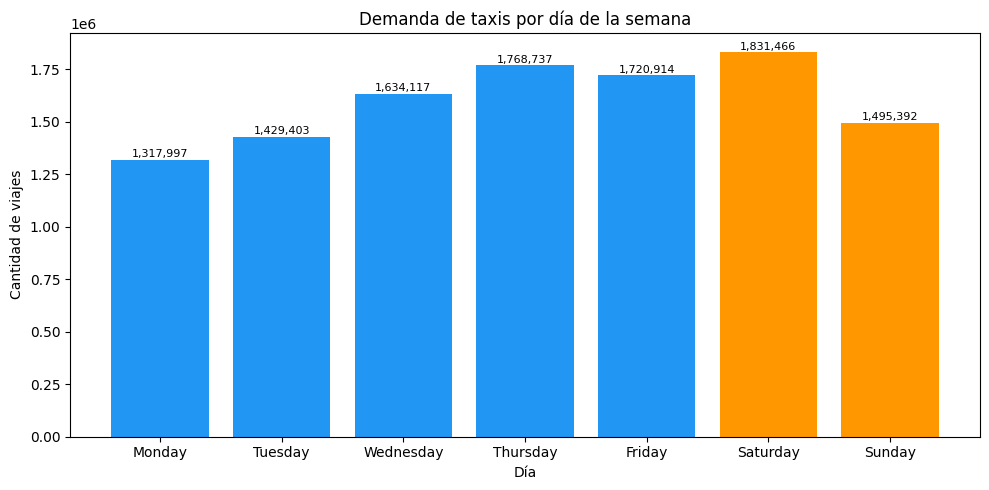

In [23]:
# Demanda por día
demand_day = (df.groupby('day_of_week')
                .size()
                .reindex(order_days)
                .reset_index(name='viajes'))
colors_day = ['#FF9800' if d in ['Saturday','Sunday'] else '#2196F3'
              for d in demand_day['day_of_week']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(demand_day['day_of_week'], demand_day['viajes'], color=colors_day)
ax.set_title('Demanda de taxis por día de la semana')
ax.set_xlabel('Día')
ax.set_ylabel('Cantidad de viajes')
for bar, val in zip(bars, demand_day['viajes']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()
plt.close('all')

El sábado es el día con mayor cantidad de viajes (1.83M), superando a todos los días laborables. Los días hábiles muestran una tendencia creciente de lunes a jueves, con una leve caída el viernes. Esto podría explicarse porque a medida que transcurre la semana, los trabajadores se saturan y prefieren llegar más rápido a casa usando taxis, explicando la tendencia vista. La pequeña caída del viernes podría ser explicada por la gente que prefiere quedarse en la ciudad y hacer planes nocturnos.

El domingo tiene la segunda menor demanda después del lunes, probablemente por la reducción de actividad nocturna del domingo a la madrugada del lunes.

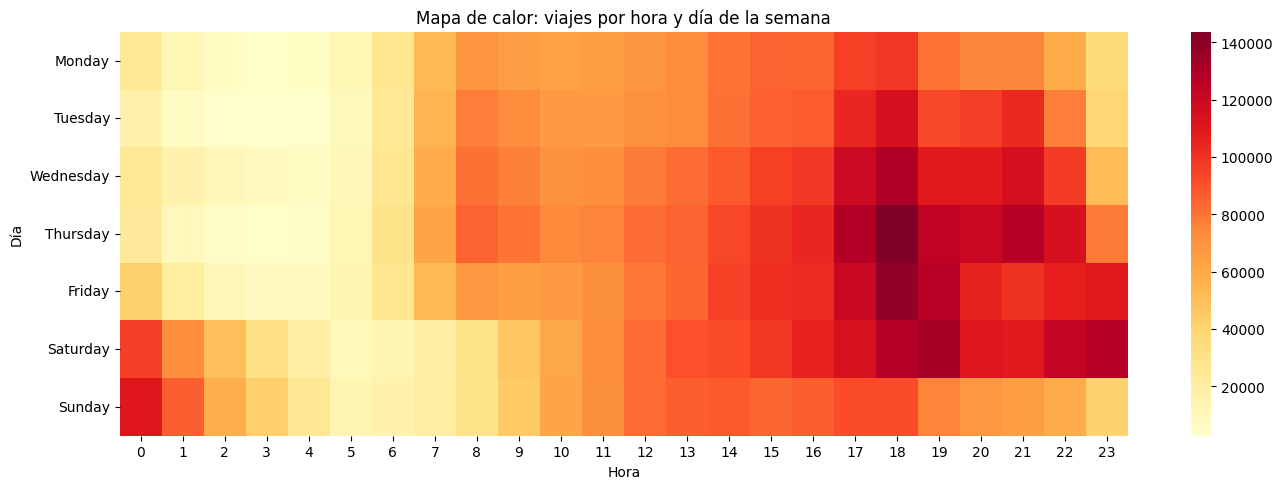

In [24]:
# Heatmap hora x día
pivot = (df.groupby(['day_of_week','hour'])
           .size()
           .unstack(fill_value=0)
           .reindex(order_days))

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, annot=False)
ax.set_title('Mapa de calor: viajes por hora y día de la semana')
ax.set_xlabel('Hora')
ax.set_ylabel('Día')
plt.tight_layout()
plt.show()
plt.close('all')

Los días laborables concentran su demanda en la franja 17-19 hs (celdas más oscuras en jueves y viernes). Esto corresponde al comportamiento esperado de las horas pico.

Los fines de semana, en cambio, muestran alta demanda sostenida desde las 0-2 AM (actividad nocturna) y a lo largo de toda la tarde, sin el pico matutino característico de los días hábiles.

Esto confirma que los fines de semana responden a una lógica de uso recreativo y nocturno, mientras que los días laborables están dominados por los desplazamientos laborales.

## Identificación y análisis de valores atípicos.

Adoptamos un enfoque en dos etapas, primero eliminamos valores físicamente imposibles usando conocimiento del dominio. Luego, sobre el conjunto ya filtrado, aplicamos los métodos estadísticos para entender la distribución de los outliers dentro del rango válido.

##### Se usan mascaras para filtrar las fechas de los viajes contenidos dentro de este análisis (1ro de Enero de 2025 a 31 de Marzo de 2025). Los valores inválidos son erradicados

In [25]:
mask_fechas_validas = (
    (df['tpep_pickup_datetime'] >= '2025-01-01') &
    (df['tpep_pickup_datetime'] < '2025-04-01')
)
print(f"Registros fuera de rango: {(~mask_fechas_validas).sum()}")
print(f"Registros dentro de rango: {mask_fechas_validas.sum()}")
df = df[mask_fechas_validas]
df.reset_index(drop=True, inplace=True)
del mask_fechas_validas
gc.collect()

Registros fuera de rango: 25
Registros dentro de rango: 11198001


38192

##### Se usan mascaras para filtrar las duraciones de los viajes mayores a 12 horas y además los que tienen el horario de finalización previo al del comienzo.

Se usa como cota máxima de duración de viaje las 12 horas porque según la TLC, los conductores de taxis pueden rehusarse a prestar servicios a partir de dicha marca.

In [26]:
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

mask_duraciones_validas = (
    (df['tpep_dropoff_datetime'] > df['tpep_pickup_datetime']) &
    (df['trip_duration'] <= 720)
)

print(f"Registros eliminados: {(~mask_duraciones_validas).sum()}")

# Filtramos sin hacer copy para no duplicar RAM
df = df[mask_duraciones_validas]
df.reset_index(drop=True, inplace=True)
del mask_duraciones_validas
gc.collect()

Registros eliminados: 32734


36

##### Tratamiento sobre el resto de variables `fare_amount`, `total_amount`,`trip_distance` y `passenger_count`

Se aplica la lógica de negocio para filtrar estos valores:
*   `passenger_count`: entre 1 y 6, es el máximo legal
*   `trip_distance`: mayores a 0 y menores a 100 millas, cubre holgadamente todos los destinos desde/hacía NYC.
*   `fare_amount`: mayores a \$3.00 ya que es la tarifa mínima de TLC
*   `total_amount`: menores a \$500 teniendo en cuenta que una tarifa base cara es \$200, con \$30 de peajes y una propina generosa del 25% nos da ~$300.



In [27]:
mask_passenger = (
    (df['passenger_count'] >= 1) &
    (df['passenger_count'] <= 6)
)
print(f"Registros eliminados por passenger_count: {(~mask_passenger).sum()}")

mask_distance = (
    (df['trip_distance'] > 0) &
    (df['trip_distance'] <= 100)
)
print(f"Registros eliminados por trip_distance: {(~mask_distance).sum()}")

mask_fare = (
    (df['fare_amount'] >= 3.00)
)
print(f"Registros eliminados por fare_amount: {(~mask_fare).sum()}")

mask_total = (
    (df['total_amount'] >= 3.0) &
    (df['total_amount'] <= 500)
)
print(f"Registros eliminados por total_amount: {(~mask_total).sum()}")

df = df[mask_passenger & mask_distance & mask_fare & mask_total]
df.reset_index(drop=True, inplace=True)

del mask_passenger, mask_distance, mask_fare, mask_total
gc.collect()

Registros eliminados por passenger_count: 2331816
Registros eliminados por trip_distance: 292749
Registros eliminados por fare_amount: 544580
Registros eliminados por total_amount: 280908


0

## Cálculo de IQR, Z-SCORE y Z-MOD

Para identificar valores atípicos en las variables cuantitativas continuas se aplicaron tres métodos complementarios, dado que cada uno tiene supuestos distintos y ninguno es suficiente por sí solo.

El método IQR define como outlier todo valor que cae por debajo de Q1 − 1.5 * IQR o por encima de Q3 + 1.5 * IQR.

El Z-score clásico mide cuántos desvíos estándar se aleja cada observación de la media. Se considera outlier todo valor con |z| > 3. Su limitación es que asume normalidad, por lo que en distribuciones sesgadas tiende a subestimar la cantidad de atípicos.

El Z-score modificado reemplaza la media por la mediana y el desvío estándar por el MAD (Median Absolute Deviation), haciéndolo más robusto frente al sesgo. Se considera outlier todo valor con |z_mod| > 3.5.

In [28]:
def z_calculation(serie):
  media = np.mean(serie)
  std = np.std(serie)
  return (serie - media) / std

def z_mod_calculation(serie):
  median = np.median(serie)
  MAD = np.median(np.absolute(serie - median))
  return (serie - median) * 0.6745 / MAD

### `fare_amount`

In [29]:
# fare_amount
Q1_fare = np.quantile(df.fare_amount, 0.25)
Q3_fare = np.quantile(df.fare_amount, 0.75)
IQR_fare = Q3_fare - Q1_fare
out_inf_fare = Q1_fare - 1.5 * IQR_fare
out_sup_fare = Q3_fare + 1.5 * IQR_fare

df["z_fare"] = z_calculation(df.fare_amount)
df["zm_fare"] = z_mod_calculation(df.fare_amount)

print(f"Límites IQR: ({out_inf_fare:.2f}, {out_sup_fare:.2f})")
print(f"Outliers Z-score:  {((df.z_fare > 3) | (df.z_fare < -3)).sum():,}")
print(f"Outliers Z-mod:    {((df.zm_fare > 3.5) | (df.zm_fare < -3.5)).sum():,}")

Límites IQR: (-8.20, 36.60)
Outliers Z-score:  370,954
Outliers Z-mod:    834,575


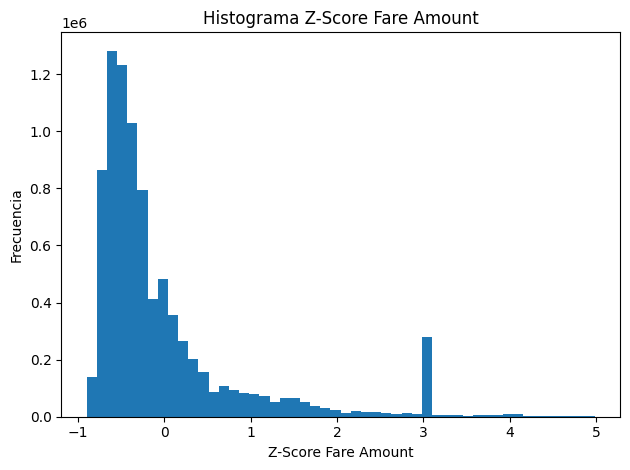

In [30]:
z_fare_filtrado = df.z_fare[(df.z_fare > -5) & (df.z_fare < 5)] # hacemos este filtrado porque como hay valores muy extremos el grafico queda aplastado y no se pueden ver los que están bien
plt.hist(z_fare_filtrado, bins=50)
plt.title("Histograma Z-Score Fare Amount")
plt.xlabel("Z-Score Fare Amount")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()
plt.close('all')

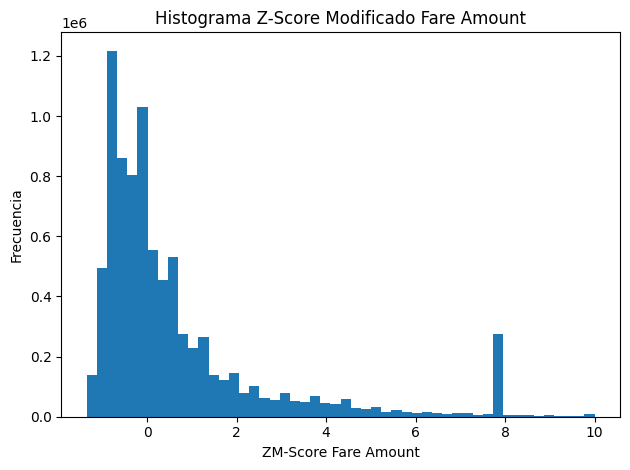

In [31]:
zm_fare_filtrado = df.zm_fare[(df.zm_fare > -10) & (df.zm_fare < 10)]
plt.hist(zm_fare_filtrado, bins=50)
plt.title("Histograma Z-Score Modificado Fare Amount")
plt.xlabel("ZM-Score Fare Amount")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()
plt.close('all')

### `trip_distance`

In [32]:
# trip_distance
Q1_dist = np.quantile(df.trip_distance, 0.25)
Q3_dist = np.quantile(df.trip_distance, 0.75)
IQR_dist = Q3_dist - Q1_dist
out_inf_dist = Q1_dist - 1.5 * IQR_dist
out_sup_dist = Q3_dist + 1.5 * IQR_dist

df["z_dist"] = z_calculation(df.trip_distance)
df["zm_dist"] = z_mod_calculation(df.trip_distance)

print(f"Límites IQR: ({out_inf_dist:.2f}, {out_sup_dist:.2f})")
print(f"Outliers Z-score:  {((df.z_dist > 3) | (df.z_dist < -3)).sum():,}")
print(f"Outliers Z-mod:    {((df.zm_dist > 3.5) | (df.zm_dist < -3.5)).sum():,}")


Límites IQR: (-2.12, 6.20)
Outliers Z-score:  347,805
Outliers Z-mod:    1,153,810


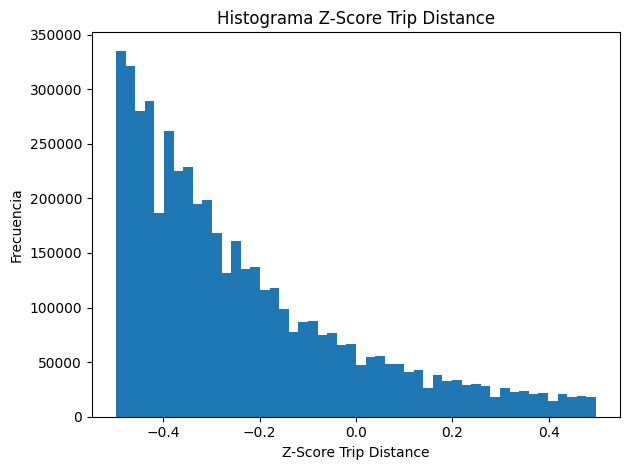

In [33]:
z_dist_filtrado = df.z_dist[(df.z_dist > -0.5) & (df.z_dist < 0.5)] # pusimos eso porque hay uno de 320000 millas que sesga todo
plt.hist(z_dist_filtrado, bins=50)
plt.title("Histograma Z-Score Trip Distance")
plt.xlabel("Z-Score Trip Distance")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()
plt.close('all')
#mencionar que para esta variable el z score es inutil

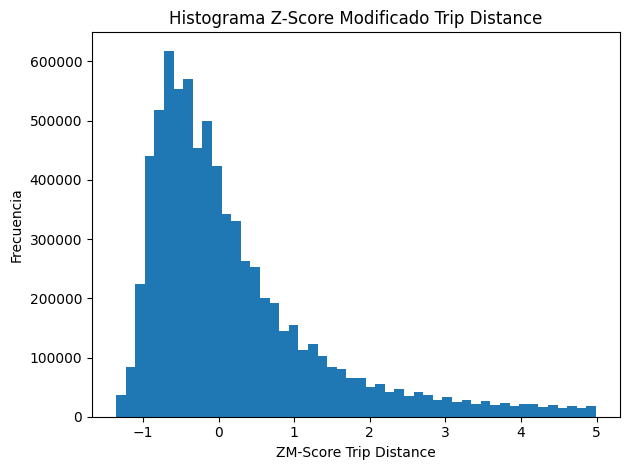

In [34]:
zm_dist_filtrado = df.zm_dist[(df.zm_dist > -5) & (df.zm_dist < 5)]
plt.hist(zm_dist_filtrado, bins=50)
plt.title("Histograma Z-Score Modificado Trip Distance")
plt.xlabel("ZM-Score Trip Distance")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()
plt.close('all')

### `tip_amount`

In [35]:
# tip_amount
Q1_tip = np.quantile(df.tip_amount, 0.25)
Q3_tip = np.quantile(df.tip_amount, 0.75)
IQR_tip = Q3_tip - Q1_tip
out_inf_tip = Q1_tip - 1.5 * IQR_tip
out_sup_tip = Q3_tip + 1.5 * IQR_tip

df["z_tip"] = z_calculation(df.tip_amount)
df["zm_tip"] = z_mod_calculation(df.tip_amount)

print(f"Límites IQR: ({out_inf_tip:.2f}, {out_sup_tip:.2f})")
print(f"Outliers Z-score:  {((df.z_tip > 3) | (df.z_tip < -3)).sum():,}")
print(f"Outliers Z-mod:    {((df.zm_tip > 3.5) | (df.zm_tip < -3.5)).sum():,}")

Límites IQR: (-3.02, 8.77)
Outliers Z-score:  226,490
Outliers Z-mod:    487,525


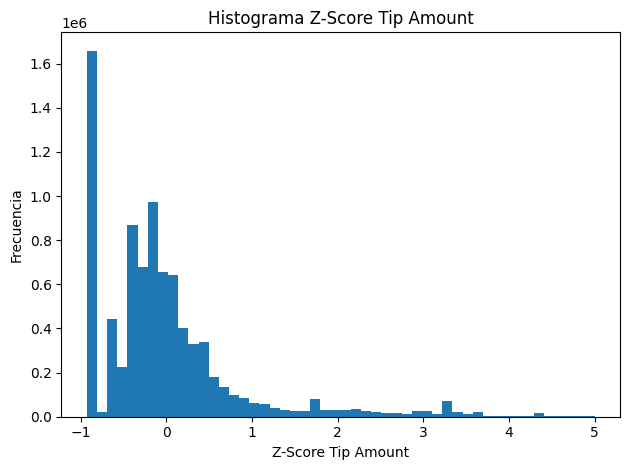

In [36]:
z_tip_filtrado = df.z_tip[(df.z_tip > -5) & (df.z_tip < 5)]
plt.hist(z_tip_filtrado, bins=50)
plt.title("Histograma Z-Score Tip Amount")
plt.xlabel("Z-Score Tip Amount")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()
plt.close('all')

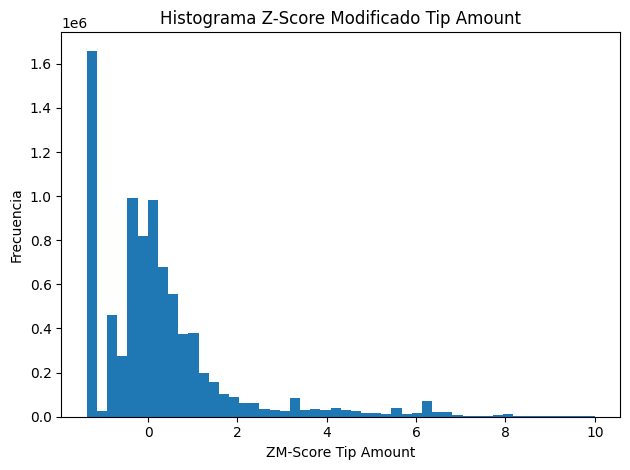

In [37]:
zm_tip_filtrado = df.zm_tip[(df.zm_tip > -10) & (df.zm_tip < 10)]
plt.hist(zm_tip_filtrado, bins=50)
plt.title("Histograma Z-Score Modificado Tip Amount")
plt.xlabel("ZM-Score Tip Amount")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()
plt.close('all')
# aca mencionar lo de las propinas en efectivo

### `total_amount`

In [38]:
# total_amount
Q1_total = np.quantile(df.total_amount, 0.25)
Q3_total = np.quantile(df.total_amount, 0.75)
IQR_total = Q3_total - Q1_total
out_inf_total = Q1_total - 1.5 * IQR_total
out_sup_total = Q3_total + 1.5 * IQR_total

df["z_total"] = z_calculation(df.total_amount)
df["zm_total"] = z_mod_calculation(df.total_amount)

print(f"Límites IQR: ({out_inf_total:.2f}, {out_sup_total:.2f})")
print(f"Outliers Z-score:  {((df.z_total > 3) | (df.z_total < -3)).sum():,}")
print(f"Outliers Z-mod:    {((df.zm_total > 3.5) | (df.zm_total < -3.5)).sum():,}")

Límites IQR: (-3.51, 48.57)
Outliers Z-score:  256,852
Outliers Z-mod:    913,347


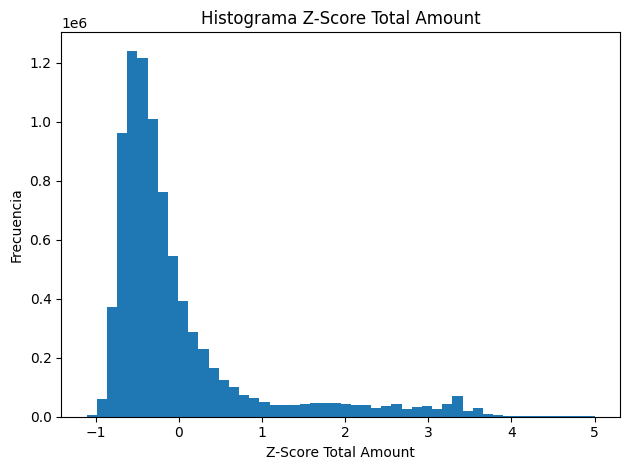

In [39]:
z_total_filtrado = df.z_total[(df.z_total > -5) & (df.z_total < 5)]
plt.hist(z_total_filtrado, bins=50)
plt.title("Histograma Z-Score Total Amount")
plt.xlabel("Z-Score Total Amount")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()
plt.close('all')

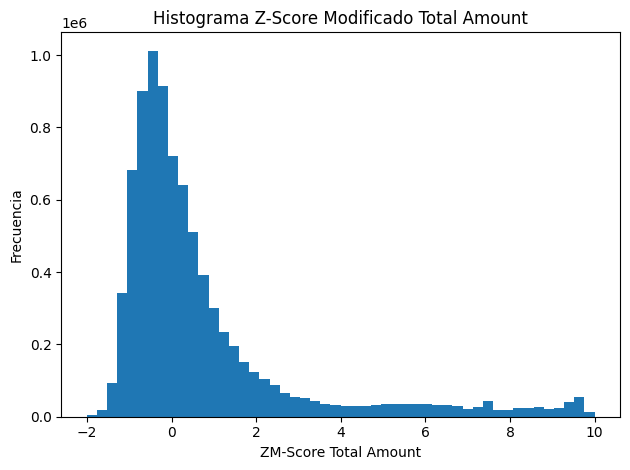

In [40]:
zm_total_filtrado = df.zm_total[(df.zm_total > -10) & (df.zm_total < 10)]
plt.hist(zm_total_filtrado, bins=50)
plt.title("Histograma Z-Score Modificado Total Amount")
plt.xlabel("ZM-Score Total Amount")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()
plt.close('all')

### `trip_duration`

In [41]:
# trip_duration
Q1_dur = np.quantile(df.trip_duration, 0.25)
Q3_dur = np.quantile(df.trip_duration, 0.75)
IQR_dur = Q3_dur - Q1_dur
out_inf_dur = Q1_dur - 1.5 * IQR_dur
out_sup_dur = Q3_dur + 1.5 * IQR_dur

df["z_dur"] = z_calculation(df.trip_duration)
df["zm_dur"] = z_mod_calculation(df.trip_duration)

print(f"Límites IQR: ({out_inf_dur:.2f}, {out_sup_dur:.2f})")
print(f"Outliers Z-score:  {((df.z_dur > 3) | (df.z_dur < -3)).sum():,}")
print(f"Outliers Z-mod:    {((df.zm_dur > 3.5) | (df.zm_dur < -3.5)).sum():,}")

Límites IQR: (-9.87, 35.73)
Outliers Z-score:  167,825
Outliers Z-mod:    438,788


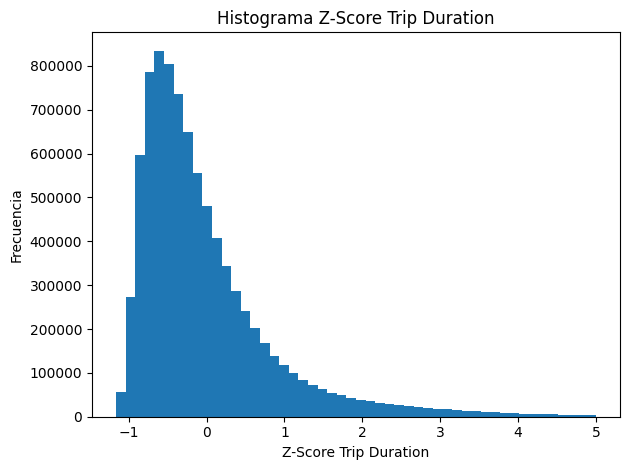

In [42]:
z_dur_filtrado = df.z_dur[(df.z_dur > -5) & (df.z_dur < 5)]
plt.hist(z_dur_filtrado, bins=50)
plt.title("Histograma Z-Score Trip Duration")
plt.xlabel("Z-Score Trip Duration")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()
plt.close('all')

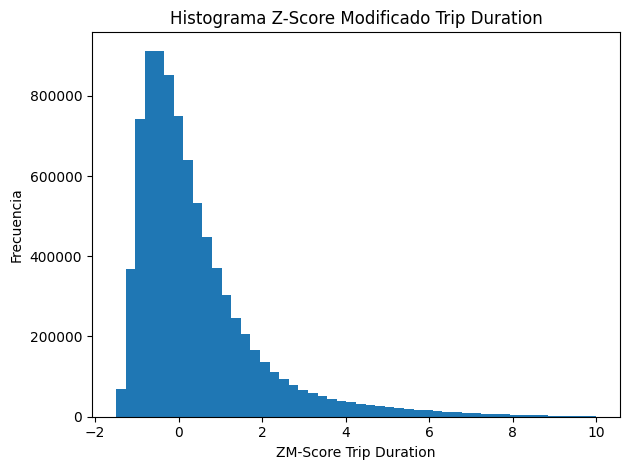

In [43]:
zm_dur_filtrado = df.zm_dur[(df.zm_dur > -10) & (df.zm_dur < 10)]
plt.hist(zm_dur_filtrado, bins=50)
plt.title("Histograma Z-Score Modificado Trip Duration")
plt.xlabel("ZM-Score Trip Duration")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()
plt.close('all')

### Tabla comparativa

In [44]:
resumen_outliers = pd.DataFrame({
    'Variable': ['fare_amount', 'trip_distance', 'tip_amount', 'total_amount', 'trip_duration'],
    'Límite IQR inferior': [out_inf_fare, out_inf_dist, out_inf_tip, out_inf_total, out_inf_dur],
    'Límite IQR superior': [out_sup_fare, out_sup_dist, out_sup_tip, out_sup_total, out_sup_dur],
    'Outliers Z-score (%)': [
        round(((df.z_fare > 3) | (df.z_fare < -3)).sum() / len(df) * 100, 2),
        round(((df.z_dist > 3) | (df.z_dist < -3)).sum() / len(df) * 100, 2),
        round(((df.z_tip > 3) | (df.z_tip < -3)).sum() / len(df) * 100, 2),
        round(((df.z_total > 3) | (df.z_total < -3)).sum() / len(df) * 100, 2),
        round(((df.z_dur > 3) | (df.z_dur < -3)).sum() / len(df) * 100, 2),
    ],
    'Outliers Z-mod (%)': [
        round(((df.zm_fare > 3.5) | (df.zm_fare < -3.5)).sum() / len(df) * 100, 2),
        round(((df.zm_dist > 3.5) | (df.zm_dist < -3.5)).sum() / len(df) * 100, 2),
        round(((df.zm_tip > 3.5) | (df.zm_tip < -3.5)).sum() / len(df) * 100, 2),
        round(((df.zm_total > 3.5) | (df.zm_total < -3.5)).sum() / len(df) * 100, 2),
        round(((df.zm_dur > 3.5) | (df.zm_dur < -3.5)).sum() / len(df) * 100, 2),
    ]
})

resumen_outliers

,Variable,Límite IQR inferior,Límite IQR superior,Outliers Z-score (%),Outliers Z-mod (%)
0,fare_amount,-8.20,36.60,4.34,9.76
1,trip_distance,-2.12,6.20,4.07,13.50
2,tip_amount,-3.02,8.77,2.65,5.70
3,total_amount,-3.51,48.57,3.00,10.68
4,trip_duration,-9.87,35.73,1.96,5.13


### Conclusión sobre valores atípicos

El análisis de valores atípicos se realizó en dos etapas con propósitos distintos.

En la primera etapa se eliminaron valores físicamente imposibles aplicando
conocimiento del dominio: fechas fuera del período enero-marzo 2025, duraciones
negativas o mayores a 12 horas, `passenger_count` fuera del rango legal (1-6),
`trip_distance` mayor a 100 millas, `fare_amount` por debajo de la tarifa mínima de la TLC (\$3.00) y `total_amount` por fuera del rango \$3-$500. En total se removieron aproximadamente 1.2 millones de registros.

En la segunda etapa se aplicaron IQR, Z-score y Z-score modificado sobre el
dataset ya filtrado para caracterizar la distribución de los valores restantes.
Los resultados muestran porcentajes de outliers estadísticos elevados en todas
las variables, particularmente con el Z-score modificado. Esto no representa
un error del análisis sino una consecuencia directa de la naturaleza de los datos.

Las variables monetarias (`fare_amount`, `total_amount`, `tip_amount`) y las de
distancia y duración presentan distribuciones fuertemente asimétricas hacia
la derecha: la gran mayoría de los viajes son cortos y baratos, pero conviven
con una minoría válida de viajes largos como traslados al aeropuerto JFK o
LaGuardia, viajes fuera de Manhattan o traslados nocturnos. Tanto el Z-score
clásico como el modificado asumen cierta simetría en los datos, por lo que
tienden a clasificar como atípico todo lo que se encuentra en la cola derecha
de la distribución aunque sean viajes perfectamente posibles dentro del negocio.

Vale destacar además que `tip_amount` presenta una particularidad estructural:
al no registrar propinas en efectivo, una proporción importante de viajes tiene
`tip_amount` = 0, lo que desplaza fuertemente la mediana hacia abajo y hace que
cualquier propina moderada aparezca como outlier estadístico.

Por estas razones se decidió no eliminar registros adicionales basándose
exclusivamente en los métodos estadísticos. Los valores que superan los filtros
de dominio se conservan como parte legítima del dataset, ya que su eliminación
introduciría un sesgo injustificado al descartar viajes reales y válidos dentro
del ecosistema de taxis de Nueva York.

### Limpieza de z-scores

In [45]:
cols_aux = [c for c in df.columns if c.startswith(('z_', 'zm_'))]
df.drop(columns=cols_aux, inplace=True)
gc.collect()

45930

## Analisis de valores faltantes




### Chequeo si todos los valores faltantes son de las mismas filas

In [46]:
# Verificar si los nulos coinciden en las mismas filas
nulos_mask = df['passenger_count'].isna()
print(df[nulos_mask][['passenger_count', 'RatecodeID', 'store_and_fwd_flag',
                        'congestion_surcharge', 'Airport_fee']].isna().all().all())
# Si devuelve True, son exactamente las mismas filas

True


### Ejemplos de filas con valores nulos para ver como se ven.


In [47]:
df[df['passenger_count'].isna()].head(20)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone,revenue,hour,day_of_week,trip_duration


## Técnicas aplicadas sobre los valores faltantes


### store_and_fwd_flag

A continuación se realizara un estudio sobre los nulos de esta variable. ¿Existe correlación entre la distancia del viaje y que esta variable se vuelva nula?.
Es una hipotesis que cobra sentido debido al significado de esta variable, ya que a mayor distancia es mas probable que el vehiculo pierda la señal con el servidor

In [48]:
# % de nulos por bin de distancia
df['distance_bin'] = pd.cut(df['trip_distance'], bins=[0, 1, 3, 5, 10, 20, 100])
null_rate = df.groupby('distance_bin')['store_and_fwd_flag'].apply(
    lambda x: x.isna().mean() * 100
)
print(null_rate)

distance_bin
(0, 1]      0.00
(1, 3]      0.00
(3, 5]      0.00
(5, 10]     0.00
(10, 20]    0.00
(20, 100]   0.00
Name: store_and_fwd_flag, dtype: float64


/tmp/ipykernel_964/4088855620.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  null_rate = df.groupby('distance_bin')['store_and_fwd_flag'].apply(


Como podemos observar los nulos se concentran en viajes de distancia media (3-10 millas) y cae abruptamente en los extremos.

Al no encontrar una correlacion monotona creciente entre la distancia y la cantidad de nulos de esta variable, vamos a continuar con un analisis contrastandola contra `PULocationID` y `DOLocationID`

In [49]:
null_rate_PU = df.groupby('PULocationID', observed=True)['store_and_fwd_flag'].apply(
    lambda x: x.isna().mean() * 100).sort_values(ascending=False)

null_rate_DO = df.groupby('DOLocationID', observed=True)['store_and_fwd_flag'].apply(
    lambda x: x.isna().mean() * 100).sort_values(ascending=False)

print("=== PU top 20 ===");  print(null_rate_PU.head(20))
print("=== PU bottom 20 ==="); print(null_rate_PU.tail(20))
print("=== DO top 20 ===");  print(null_rate_DO.head(20))
print("=== DO bottom 20 ==="); print(null_rate_DO.tail(20))

=== PU top 20 ===
PULocationID
265   0.00
1     0.00
2     0.00
249   0.00
248   0.00
247   0.00
246   0.00
245   0.00
244   0.00
243   0.00
242   0.00
241   0.00
240   0.00
239   0.00
238   0.00
237   0.00
236   0.00
235   0.00
234   0.00
35    0.00
Name: store_and_fwd_flag, dtype: float64
=== PU bottom 20 ===
PULocationID
253   0.00
252   0.00
251   0.00
250   0.00
19    0.00
18    0.00
17    0.00
16    0.00
15    0.00
14    0.00
13    0.00
12    0.00
11    0.00
10    0.00
9     0.00
8     0.00
7     0.00
6     0.00
5     0.00
4     0.00
Name: store_and_fwd_flag, dtype: float64
=== DO top 20 ===
DOLocationID
265   0.00
1     0.00
2     0.00
3     0.00
249   0.00
248   0.00
247   0.00
246   0.00
245   0.00
244   0.00
243   0.00
242   0.00
241   0.00
240   0.00
239   0.00
238   0.00
237   0.00
236   0.00
235   0.00
234   0.00
Name: store_and_fwd_flag, dtype: float64
=== DO bottom 20 ===
DOLocationID
253   0.00
252   0.00
251   0.00
250   0.00
20    0.00
19    0.00
18    0.00
17    0.00

La zona de pickup explica una variabilidad mucho mas grande que la zona de dropoff. Si el mecanismo fuera del trayecto, ambos extremos del viaje deberían tener tasas comparables.

Algunas zonas aparecen en el "top de nulos" de PU y en el "bottom de nulos" de DO, o viceversa. La misma zona física genera 90%+ de nulos cuando es origen, pero menos del 10% cuando es destino.

In [50]:
print("=== % de nulos en store_and_fwd_flag por VendorID ===")
print(pd.crosstab(df['VendorID'],
                  df['store_and_fwd_flag'].isna(),
                  normalize='index') * 100)

print("\n=== Volumen absoluto por VendorID ===")
print(df['VendorID'].value_counts(dropna=False))

=== % de nulos en store_and_fwd_flag por VendorID ===
store_and_fwd_flag  False
VendorID                 
1                  100.00
2                  100.00

=== Volumen absoluto por VendorID ===
VendorID
2    6641904
1    1906053
6          0
7          0
Name: count, dtype: int64


Los vendors minoritarios Myle Technologies (ID 6) y Helix (ID 7), recientemente incorporados al ecosistema, muestran comportamientos extremos (100% y 0% de nulos respectivamente), lo que sugiere que se trata de flotas pequeñas

Decisión sobre `store_and_fwd_flag`: el análisis del patrón de faltantes revelo que la tasa de nulos por bin de distancia es no monótona, lo que descarta una causa ligada a la longitud del viaje. Además, las tasas por zona de pickup son mucho mas extremas que por zona de dropoff, descartando un mecanismo asociado al trayecto y apuntando a un factor ligado a la flota que opera en el origen. El crosstab con VendorID muestra que los proveedores mayoritarios tienen tasas heterogéneas (14% en VendorID 1, 22% en VendorID 2) y los vendors minoritarios (VendorID 6 y VendorID 7) muestran comportamientos extremos (100% y 0% de nulos respectivamente).

El conjunto sugiere que el mecanismo es MAR condicionado a proveedor + sub-flota geográfica, no MCAR ni MNAR. Decidimos eliminar la columna en lugar de imputarla, ya que cualquier imputación introduciría sesgo sistemático en zonas y vendors específicos sin aportar señal real.

In [51]:
df = df.drop(columns=['store_and_fwd_flag'])
# limpiamos el bin auxiliar si todavía está
if 'distance_bin' in df.columns:
    df = df.drop(columns=['distance_bin'])

### Airport_fee

Se utilizará `taxi_zone_lookup.csv` para identificar qué `PULocationID` corresponden a aeropuertos (JFK y LaGuardia). Con esa información, se imputará `Airport_fee` con 1.75 si el pickup fue en esos aeropuertos, y 0 en el resto de los casos.

In [52]:
# Cargo zone_lookup
zone_lookup = pd.read_csv('https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv')

# Inferir el monto vigente desde los datos (no hardcodear)
print("Valores no nulos de Airport_fee:")
print(df.loc[df['Airport_fee'] > 0, 'Airport_fee'].value_counts().head())

# Identifico IDs de JFK y LaGuardia
airport_zones = zone_lookup[zone_lookup['Zone'].str.contains("JFK|LaGuardia", case=False, na=False)]['LocationID'].tolist()
print(f"IDs de aeropuertos: {airport_zones}")

# Imputo: 1.75 si el pickup fue en aeropuerto y el valor era NaN, 0 si era NaN y no es aeropuerto
mask_nulo = df['Airport_fee'].isna()
mask_aeropuerto = df['PULocationID'].isin(airport_zones)

df.loc[mask_nulo & mask_aeropuerto, 'Airport_fee'] = 1.75
df.loc[mask_nulo & ~mask_aeropuerto, 'Airport_fee'] = 0.0

# Verifico que no hayan nulos
print(f"Nulos restantes en Airport_fee: {df['Airport_fee'].isna().sum()}")

Valores no nulos de Airport_fee:
Airport_fee
1.75    666281
1.25         3
5.00         1
Name: count, dtype: int64
IDs de aeropuertos: [132, 138]
Nulos restantes en Airport_fee: 0


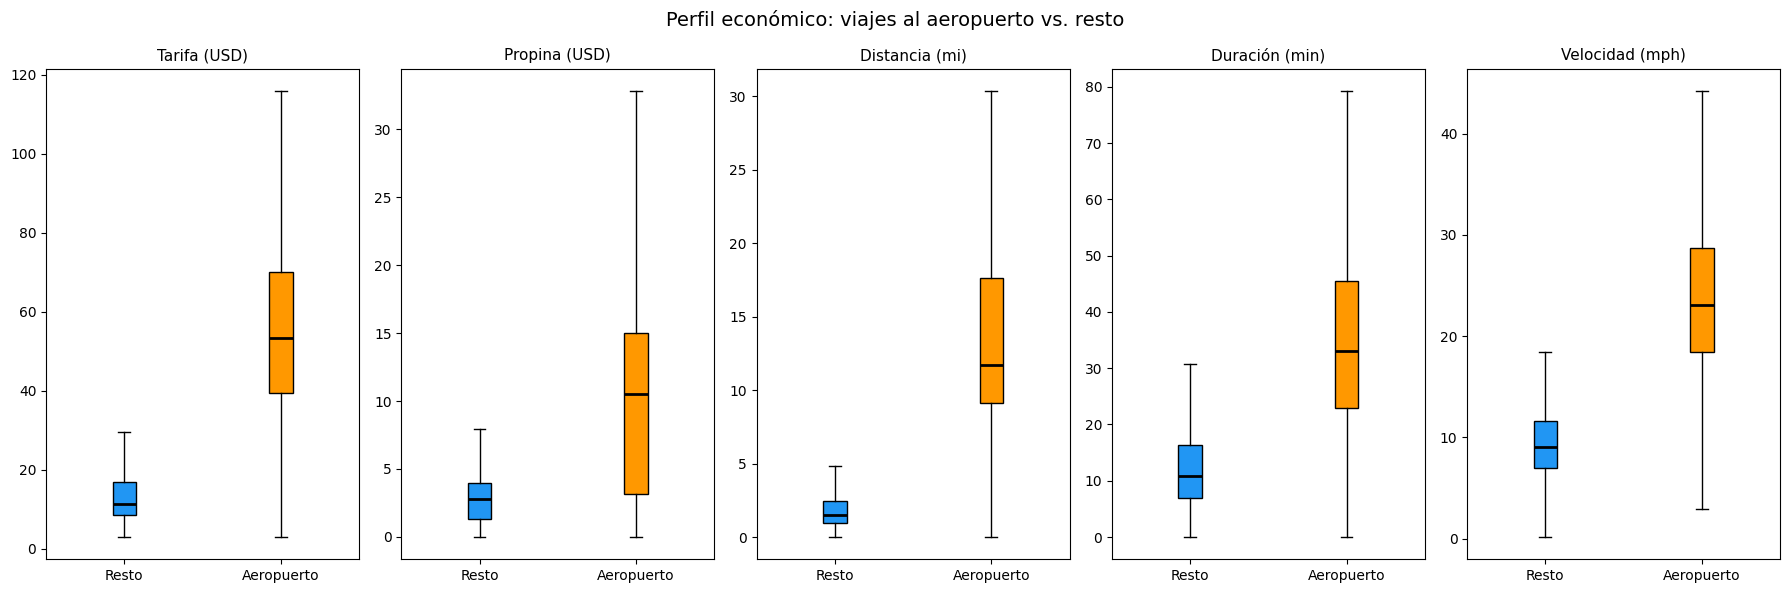

            fare_amount  tip_amount  trip_distance  trip_duration  speed_mph
Resto             11.40        2.81           1.50          10.78       9.02
Aeropuerto        53.40       10.52          11.75          33.12      23.06


In [53]:
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
df['speed_mph'] = df['trip_distance'] / (df['trip_duration'] / 60)
df.loc[df['speed_mph'] > 100, 'speed_mph'] = np.nan
airport_ids = [132, 138]  # JFK y LaGuardia
df['es_aeropuerto'] = (
    df['PULocationID'].isin(airport_ids) |
    df['DOLocationID'].isin(airport_ids)
)

vars_eco   = ['fare_amount','tip_amount','trip_distance','trip_duration','speed_mph']
labels_eco = ['Tarifa (USD)','Propina (USD)','Distancia (mi)','Duración (min)','Velocidad (mph)']

fig, axes = plt.subplots(1, len(vars_eco), figsize=(18, 6))
for ax, col, lbl in zip(axes, vars_eco, labels_eco):
    data = [df[df['es_aeropuerto'] == v][col].dropna() for v in [False, True]]
    bp = ax.boxplot(data, tick_labels=['Resto','Aeropuerto'],
                    patch_artist=True, showfliers=False,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#2196F3')
    bp['boxes'][1].set_facecolor('#FF9800')
    ax.set_title(lbl, fontsize=11)

plt.suptitle('Perfil económico: viajes al aeropuerto vs. resto', fontsize=14)
plt.tight_layout()
plt.show()

# Tabla resumen
resumen_aero = df.groupby('es_aeropuerto')[vars_eco].median().round(2)
resumen_aero.index = ['Resto', 'Aeropuerto']
print(resumen_aero)

df = df.drop(columns=['es_aeropuerto'])

### congestion_surcharge

Esta variable es un cargo extra que se cobra a los usuarios cuando el taxi transita por la zona de máximo tránsito de la ciudad. Para los taxis amarillos es un valor constante de $2.50.

Se realiza un análisis de los distintos valores que toma esta variable

In [54]:
# Analizo cuantas veces aparece cada uno
df['congestion_surcharge'].value_counts(dropna=False)

,count
congestion_surcharge,
2.50,7952093
0.00,595863
1.00,1


Como se puede observar, hay muchos valores que no toman valores válidos.
Se van a reescribir los valores presentes en esta variable con los valores validos que indica la TLC por ley.

2.5 → Zonas dentro de la zona de congestion

0 → fuera de la zona

Las dentro de la zona de congestion es todo Manhattan al sur de la '96th Street'

In [55]:
# los barrios que están al NORTE de la 96th St
zonas_norte_96 = [
    'East Harlem North', 'East Harlem South', 'Central Harlem',
    'Central Harlem North', 'Morningside Heights', 'Manhattanville',
    'Hamilton Heights', 'Washington Heights North', 'Washington Heights South',
    'Inwood', 'Inwood Hill Park', 'Marble Hill', 'Randalls Island'
]

# Zonas de Manhattan al SUR de la 96th (donde aplica el cargo)
zonas_congestion = zone_lookup[
    (zone_lookup['Borough'] == 'Manhattan') &
    (~zone_lookup['Zone'].isin(zonas_norte_96))
]['LocationID'].tolist()

# Reemplazo los valores invalidos por NaN
df.loc[~df['congestion_surcharge'].isin([0.0, 2.5]), 'congestion_surcharge'] = None

# Reemplazo los valores invalidos por los que le corresponden respecto a su zona
mask_nulo = df['congestion_surcharge'].isna()
mask_zona = df['PULocationID'].isin(zonas_congestion) | df['DOLocationID'].isin(zonas_congestion)

df.loc[mask_nulo & mask_zona, 'congestion_surcharge'] = 2.5
df.loc[mask_nulo & ~mask_zona, 'congestion_surcharge'] = 0.0

# Verifico resultado final
print(df['congestion_surcharge'].value_counts(dropna=False))

congestion_surcharge
2.50    7952094
0.00     595863
Name: count, dtype: int64


### passenger_count

Decidimos utilizar la moda para llenar los valores faltantes dado que es una variable discreta que no toma tantos valores distintos. Por otro lado si eligieramos utilizar la media, esto daría resultados decimales que no son representativos de una variable discreta

In [56]:
moda_pasajeros = df['passenger_count'].mode()[0]
df['passenger_count'] = df['passenger_count'].fillna(moda_pasajeros)

### RatecodeID

Decidimos utilizar la moda para llenar los valores faltantes dado que es una variable cualitativa nominal. Utilizar otros métodos como Cold Deck o Hot Deck parece extremadamente complejo para una variable que tiene una dsitribución tan concentrada sobre un único valor

In [57]:
moda_ratecodeID = df['RatecodeID'].mode()[0]
df['RatecodeID'] = df['RatecodeID'].fillna(moda_ratecodeID)

### Analisis de la cantidad de nulos luego de generar nuevos features

In [58]:
print("Nulos restantes tras imputaciones:")
print(df[['Airport_fee', 'congestion_surcharge', 'passenger_count', 'RatecodeID']].isna().sum())

Nulos restantes tras imputaciones:
Airport_fee             0
congestion_surcharge    0
passenger_count         0
RatecodeID              0
dtype: int64


## Feature Engineering

### Variables temporales derivadas

Las nuevas columnas profundizan en el análisis de la hora de comienzo del viaje para facilitar el estudio de los datos.

No se realizan sobre la hora de finalización ya que no lo consideramos relevante

In [59]:
df['hour']        = df['tpep_pickup_datetime'].dt.hour
df['day_of_week'] = df['tpep_pickup_datetime'].dt.day_name()
df['month']       = df['tpep_pickup_datetime'].dt.month_name()
df['is_weekend']  = df['day_of_week'].isin(['Saturday', 'Sunday'])

### Hora pico (rush hour)

Según los patrones reales de NYC, estan son de Lunes a Viernes de 7:00 a 9:00 y de 16:00 a 19:00.

In [60]:
df['rush_hour'] = (
    (~df['is_weekend']) &
    (
        df['hour'].between(7, 8) |
        df['hour'].between(16, 18)
    )
)

### Velocidad promedio del viaje

Es una variable útil para detectar congestión y comparar zonas.

In [61]:
df['speed_mph'] = df['trip_distance'] / (df['trip_duration'] / 60)

# Filtrar velocidades físicamente imposibles (> 100 mph en ciudad)
df.loc[df['speed_mph'] > 100, 'speed_mph'] = np.nan

### Tasa de propina (solo para pagos con tarjeta)

`trip_amount` no registra propinas en efectivo, por lo que la tasa solo tiene sentido para `payment_type == 1`

In [62]:
mask_payment = df['payment_type'] == 1
df.loc[mask_payment, 'tip_rate'] = df.loc[mask_payment, 'tip_amount'] / df.loc[mask_payment, 'fare_amount']

### Total pagado por pasajero

En NYC es muy común el compartir viajes para abaratar costos de transporte dentro de la ciudad, por lo que consideramos interesante analizar el valor pagado por pasajero

In [63]:
df['total_per_passenger'] = df['total_amount'] / df['passenger_count']

### Visualización de nuevas features

In [64]:
df.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,revenue,hour,day_of_week,trip_duration,speed_mph,month,is_weekend,rush_hour,tip_rate,total_per_passenger
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.00,1.60,1.00,229,237,1,10.00,...,13.00,0,Wednesday,8.35,11.50,January,False,False,0.30,18.00
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.00,0.50,1.00,236,237,1,5.10,...,7.12,0,Wednesday,2.55,11.76,January,False,False,0.40,12.12
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.00,0.60,1.00,141,141,1,5.10,...,7.10,0,Wednesday,1.95,18.46,January,False,False,0.39,12.10
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.00,0.52,1.00,244,244,2,7.20,...,NaN,0,Wednesday,5.57,5.60,January,False,False,NaN,3.23
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.00,0.66,1.00,244,116,2,5.80,...,NaN,0,Wednesday,3.53,11.21,January,False,False,NaN,2.77
5,2,2025-01-01 00:48:24,2025-01-01 01:08:26,2.00,2.63,1.00,239,68,2,19.10,...,NaN,0,Wednesday,20.03,7.88,January,False,False,NaN,12.05
6,2,2025-01-01 00:00:02,2025-01-01 00:09:36,1.00,1.71,1.00,237,262,2,11.40,...,NaN,0,Wednesday,9.57,10.72,January,False,False,NaN,16.40
7,2,2025-01-01 00:20:28,2025-01-01 00:28:04,1.00,2.29,1.00,237,75,2,11.40,...,NaN,0,Wednesday,7.60,18.08,January,False,False,NaN,16.40
8,2,2025-01-01 00:33:58,2025-01-01 00:37:23,1.00,0.56,1.00,263,236,1,5.80,...,7.96,0,Wednesday,3.42,9.83,January,False,False,0.37,12.96
9,2,2025-01-01 00:42:40,2025-01-01 00:55:38,3.00,1.99,1.00,236,151,2,14.20,...,NaN,0,Wednesday,12.97,9.21,January,False,False,NaN,6.40


## Respuestas a preguntas de investigación

### 1)

Como analizamos anteriormente, en **Análisis de consumo por hora y día**, la demanda muestra un pico máximo a las 18 hs (~840.000 viajes) y cae
fuertemente entre las 3 y las 5 AM. El sábado es el día con más viajes
(1.831.466), superando a todos los días hábiles. El heatmap confirma
que el fin de semana tiene actividad nocturna extendida hasta las 2 AM.
La hipótesis se confirma parcialmente: el pico vespertino apareció
como se esperaba, pero el sábado superó a todos los días hábiles,
lo cual no era esperado.

### 2)

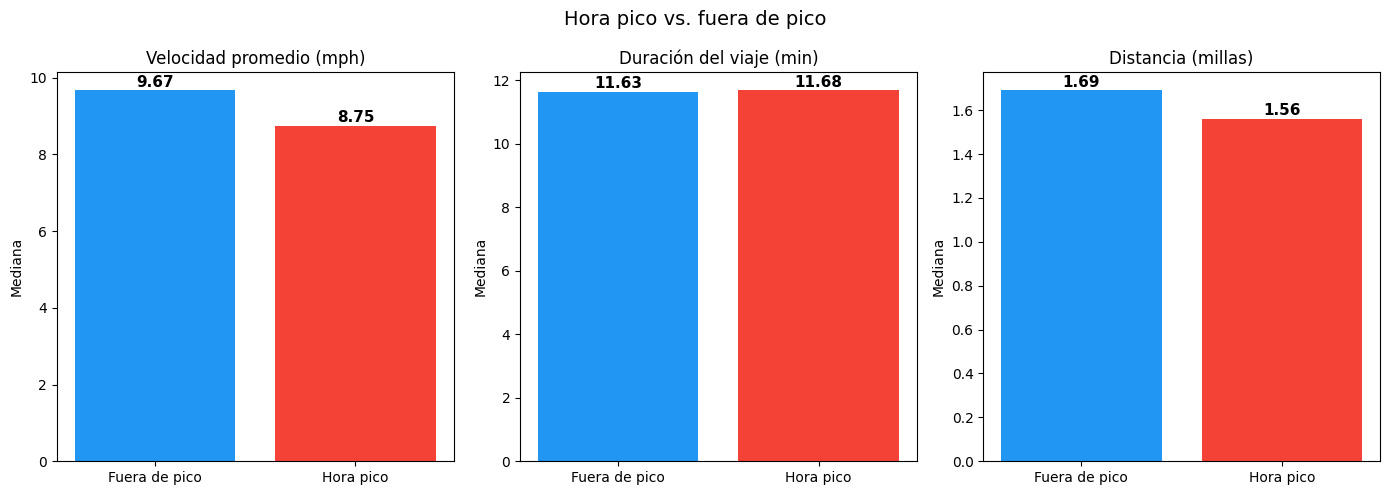

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = [
    ('speed_mph',     'Velocidad promedio (mph)'),
    ('trip_duration', 'Duración del viaje (min)'),
    ('trip_distance', 'Distancia (millas)'),
]
for ax, (col, title) in zip(axes, metrics):
    medians = [df[df['rush_hour'] == v][col].median() for v in [False, True]]
    bars = ax.bar(['Fuera de pico','Hora pico'], medians,
                  color=['#2196F3','#F44336'])
    ax.set_title(title)
    ax.set_ylabel('Mediana')
    for bar, val in zip(bars, medians):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Hora pico vs. fuera de pico', fontsize=14)
plt.tight_layout()
plt.show()

En hora pico la velocidad mediana cae de 9.67 a 8.75 mph (-10.6%) y los viajes son además más cortos en distancia (1.69 vs 1.56 millas), con una duración prácticamente igual. Esto sugiere que en hora pico se toman taxis para desplazamientos cortos en zonas congestionadas, no para viajes equivalentes a los de otros horarios.

### 3)

Newark Airport es la zona que más rentabilidad mediana genera (110 USD), seguido por South Ozone Park (92 USD) y las afueras de NYC (90 USD).

A nivel borough, EWR encabeza (110 USD), lo sigue Staten Island (93 USD) y Queens tercero con (63.91 USD). Manhattan, pese a tener el mayor volumen, tiene el revenue mediano más bajo (14.29 USD), evidenciando la tensión entre volumen y rentabilidad por viaje.

Todo este análisis puede verse en el apartado **Zonas y boroughs más frecuentes**

### 4)

            fare_amount  tip_amount  trip_distance  trip_duration  speed_mph
Resto             12.10        2.88           1.60          11.32       9.30
Aeropuerto        70.00       15.30          17.85          45.15      23.65


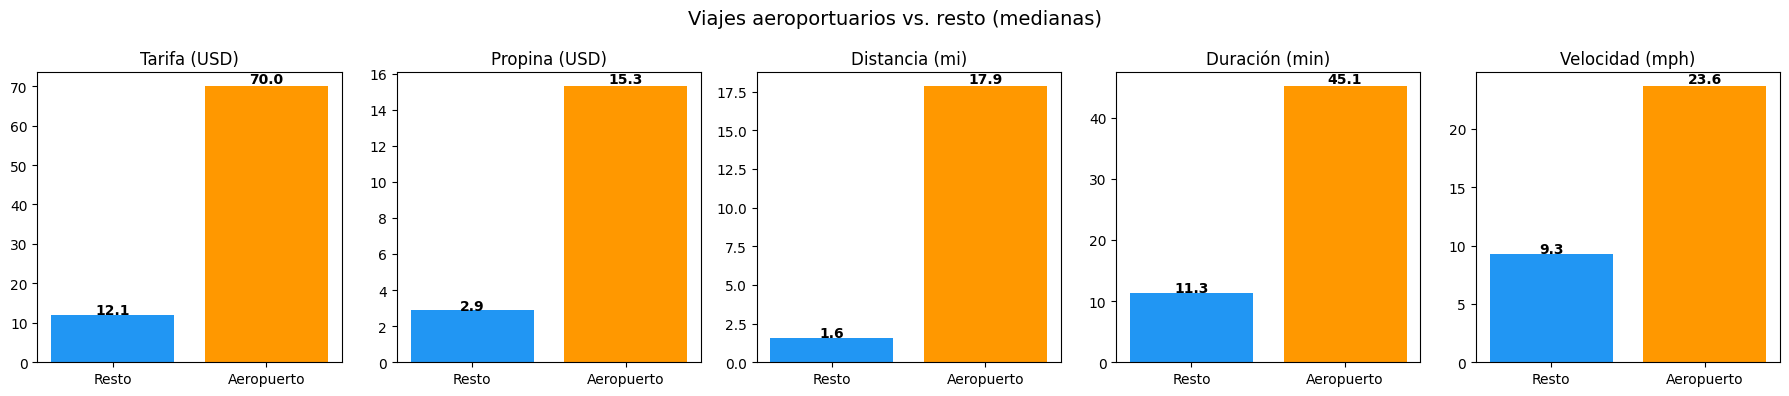

In [66]:
df['is_airport'] = df['RatecodeID'].astype(str).isin(['2.0', '3.0'])

airport_comp = df.groupby('is_airport')[
    ['fare_amount', 'tip_amount', 'trip_distance', 'trip_duration', 'speed_mph']
].median().round(2)
airport_comp.index = ['Resto', 'Aeropuerto']
print(airport_comp)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
metrics = [('fare_amount', 'Tarifa (USD)'), ('tip_amount', 'Propina (USD)'),
           ('trip_distance', 'Distancia (mi)'), ('trip_duration', 'Duración (min)'),
           ('speed_mph', 'Velocidad (mph)')]
for ax, (col, title) in zip(axes, metrics):
    vals = airport_comp[col].values
    bars = ax.bar(['Resto', 'Aeropuerto'], vals, color=['#2196F3', '#FF9800'])
    ax.set_title(title)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{v:.1f}', ha='center', fontweight='bold')
plt.suptitle('Viajes aeroportuarios vs. resto (medianas)', fontsize=14)
plt.tight_layout()
plt.show()

df = df.drop(columns=['is_airport'])

Los viajes aeroportuarios más que quintuplican la tarifa mediana del resto (70 USD vs 13 USD), tienen mayor propina, mayor distancia, mayor duracion y mayor velocidad al transcurrir parte del trayecto por autopistas. Son el tipo de viaje más conveniente para el taxista en términos de ingreso por kilómetro. La hipótesis se confirma.

### 5)

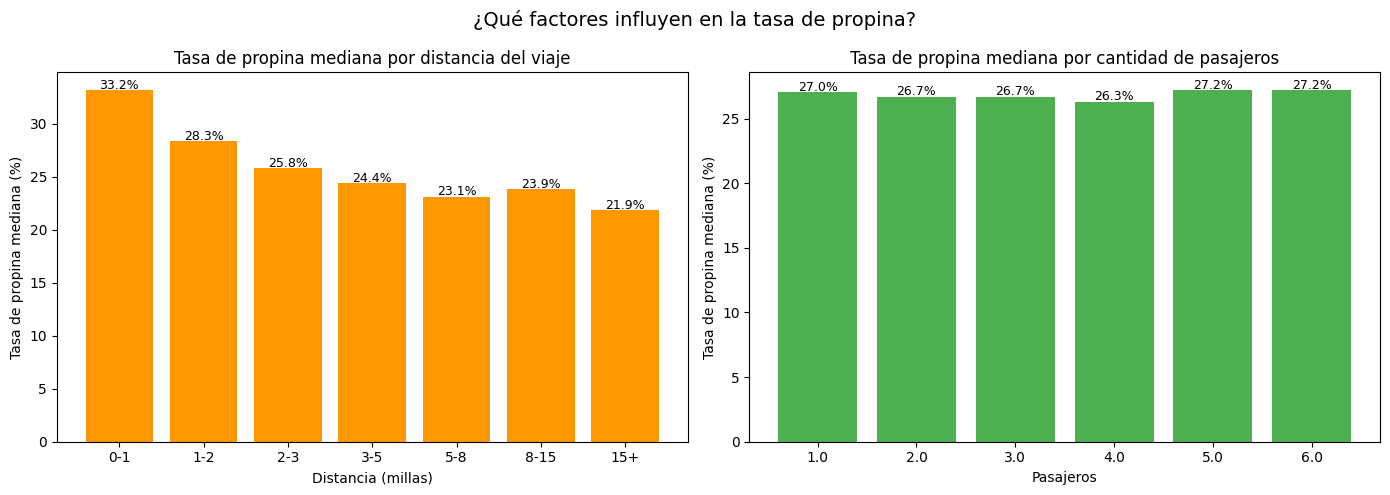

9

In [67]:
cols = ['trip_distance', 'tip_rate', 'passenger_count']
df_tips = df.loc[df['payment_type'] == 1, cols]

df_tips = df_tips.assign(
    dist_bin=pd.cut(df_tips['trip_distance'],
                    bins=[0,1,2,3,5,8,15,100],
                    labels=['0-1','1-2','2-3','3-5','5-8','8-15','15+'])
)

tip_dist = (df_tips.groupby('dist_bin', observed=True)['tip_rate']
                   .median().reset_index())

tip_pax = (df_tips.groupby('passenger_count', observed=True)['tip_rate']
                  .agg(['median','count'])
                  .query('count >= 200')
                  .reset_index())
del df_tips
gc.collect()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(tip_dist['dist_bin'], tip_dist['tip_rate'] * 100, color='#FF9800')
axes[0].set_title('Tasa de propina mediana por distancia del viaje')
axes[0].set_xlabel('Distancia (millas)')
axes[0].set_ylabel('Tasa de propina mediana (%)')
for bar, val in zip(axes[0].patches, tip_dist['tip_rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val*100:.1f}%', ha='center', fontsize=9)

axes[1].bar(tip_pax['passenger_count'].astype(str),
            tip_pax['median'] * 100, color='#4CAF50')
axes[1].set_title('Tasa de propina mediana por cantidad de pasajeros')
axes[1].set_xlabel('Pasajeros')
axes[1].set_ylabel('Tasa de propina mediana (%)')
for bar, val in zip(axes[1].patches, tip_pax['median']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val*100:.1f}%', ha='center', fontsize=9)

plt.suptitle('¿Qué factores influyen en la tasa de propina?', fontsize=14)
plt.tight_layout()
plt.show()

gc.collect()

La tasa de propina decrece monotónamente con la distancia: 33.2% en
viajes de 0-1 millas hasta 21.9% en viajes de 15+ millas, lo que
contradice nuestra hipótesis inicial. Los pasajeros en cambio no
influyen: la tasa se mantiene estable entre 26.3% y 27.2%
independientemente del grupo. La propina es un comportamiento
individual del pagador que no escala con el tamaño del grupo.

## Guardado del dataset procesado

In [68]:
import os

# Guardamos en parquet para preservar los tipos de datos
# (categoricals, datetime, Int64) sin pérdida de información
nombre = "TA047R_TP1_GRUPO02_EJ1_yellow_cab_procesado.parquet"
df.to_parquet(nombre, index=False)

# Verificación
size_mb = os.path.getsize(nombre) / (1024 ** 2)
print(f"Dataset guardado: {nombre}")
print(f"Tamaño: {size_mb:.1f} MB")
print(f"Shape: {df.shape}")
print("\nColumnas finales:")
print(df.dtypes.to_string())

Dataset guardado: TA047R_TP1_GRUPO02_EJ1_yellow_cab_procesado.parquet
Tamaño: 311.9 MB
Shape: (8547957, 35)

Columnas finales:
VendorID                       category
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                     category
PULocationID                   category
DOLocationID                      int32
payment_type                   category
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
pickup_borough                 category
pickup_zone                    category
pickup_service_zone            ca